In [1]:
import os
import glob
import itertools
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import chirp, find_peaks, peak_widths

In [2]:
# 定义函数

def separate_session(df, threshold=3):
    df = pd.read_csv(df, index_col=0)
    df['index_col'] = pd.to_numeric(df.index, errors='coerce')
    check_points = [0]  # 初始化第一个分割点为0（DataFrame的起始位置）
    frame_list = df['index_col'].values.tolist()
    

    # 判断两行之间的时间差，大于threshold则视为新的session
    for i in range(len(frame_list) - 1):
        if (frame_list[i+1] - frame_list[i]) > threshold:
            check_points.append(frame_list[i+1])
    
    check_points.append(frame_list[-1] + 1)  # 添加最后一个分割点

    session_dfs = []
    for i in range(len(check_points) - 1):
        session_df = df[(df['index_col'] >= check_points[i]) & (df['index_col'] < check_points[i+1])]
        session_df.drop(columns='index_col', inplace=True)
        session_dfs.append(session_df)

    return session_dfs
   
 

# 处理分离后的session文件，使每个session的开始时间为0
def process_frame(df):
    # 获取DataFrame的index并转换为float类型的list
    index_list = [float(index) for index in df.index]

    # 判断第一个index的值是否为0，并进行相应处理
    if index_list[0] != 0:
        # 如果第一个index的值不为0，将所有index值减去第一个index值，以实现“相对于第一个index的增量”效果
        index_list = [index - index_list[0] for index in index_list]

    return index_list

  
def process_event_interval(df):
    # 从DataFrame中提取'From Second'和'To Second'列，并转换为二维列表
    event_list = df[['From Second', 'To Second']].values.tolist()

    # 返回处理后的新事件列表
    return event_list



# 获得事件标记
def get_event_label(event_df):
    
    '''
    Aim:
        for OFT
        translate 'event' in eventFile to integer label
        each row (corresponding to each time interval) of event is assigned a label
        called in function `add_event_label()`
    '''
    
    # get event status list
    Event_status = event_df['Event'].values.tolist()
    # compact event label list for three sessions
    event_label = []
    for i in Event_status:   
        if i.strip() == 'sniff':
            event_label.append(11)
        elif i.strip() == 'sniffed' :
            event_label.append(12)
        elif i.strip() == 'freezing':
            event_label.append(21)
        elif i.strip() == 'cs':
            event_label.append(22)
        elif i.strip() == 'In_all':
            event_label.append(23)
        else:
            event_label.append(24)

    return(event_label)


# 添加事件标签
def add_event_label(trace_df, event_path):

    '''
    Aim:
        add event_label to each frame
        one frame can have several label (since mouse can in a location and do something)
    
    Retrun:
        trace dataframe with one label column
    '''
    
    frame_list = process_frame(trace_df)
    #get event dataframe/eventIntervals/eventLabel
#     event_df = pd.read_csv(event_path)
    event_df = pd.read_excel(event_path)
    interval_list = process_event_interval(event_df)
    event_label = get_event_label(event_df)

    
    # add label to each frame
    frame_label_list = []
    for frame in frame_list:
        frame_label = str()
        
        for i in range(len(interval_list)): # one frame can be in several interval
            if min(interval_list[i])  <= frame <= max(interval_list[i]) :
                frame_label = frame_label+ str(event_label[i])

        # convert str to int
        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        # append frame label to list
        frame_label_list.append(frame_label)
    
    
    # add label list to trace df 
    new_df = trace_df.copy()
    new_df['Frame_Label']  =  frame_label_list
    new_df = new_df.dropna()
    

    return(new_df)


In [3]:
# 检查特定状态下的帧间隔，并返回满足条件的数据子集
def check_frame_interval(df, which_status_to_check_frame):
    
    # set up which_status_to_check_frame
    
    if which_status_to_check_frame == 'sniff':
        which_status_to_check_frame = str(11)
    elif which_status_to_check_frame == 'sniffed':
        which_status_to_check_frame = str(12)
    elif which_status_to_check_frame == 'freezing':
        which_status_to_check_frame = str(21)
    elif which_status_to_check_frame == 'cs':
        which_status_to_check_frame = str(22)
    elif which_status_to_check_frame == 'In_all':
        which_status_to_check_frame = str(23)
    else:
        raise ValueError('Not approved status. choose from: Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_all, In_left')

    #df = add_event_label(df, event_1_path, event_2_path, event_3_path, mice_path)[which_session]
    frame_label_list = df['Frame_Label'].values.tolist()
    
    # to separate status label, eg:20214111
    n = 2
    
    check_frame_label_list = []
    for line in frame_label_list:
        line = str(line)
        line_list= [line[i:i+n] for i in range(0, len(line), n)]
        if which_status_to_check_frame in line_list:
            check_frame_label_list.append(1)
        else:
            check_frame_label_list.append(0)       
            
    
            
    df['status'] = check_frame_label_list
    df_keep = df[ (df['status'] == 1)]
    df_keep = df_keep.drop('status', axis = 1)
    df_keep = df_keep.drop('Frame_Label', axis = 1)
    
    print('the shape of the dataframe in the status is:', df_keep.shape)
    print(df_keep.head(3))
    return(df_keep)
    


In [4]:
# 计算给定数据框中每两个单元格之间的相关性，并返回相关性值的列表
def corr_list(df):
    end_range = df.shape[1]  # 获取数据框的列数
    corr_list = []  # 初始化存储相关性值的列表
    
    # 检查数据框的行数是否大于2，如果是，则继续执行相关性计算
    if df.shape[0] > 2:
        # 将数据框中的值转换为浮点数，以便进行计算
        df = df.astype(float)
        
        # 使用两层循环遍历每一对列，计算皮尔逊相关系数
        for i in range(end_range):
            a = i + 1
            for a in range(a, end_range):
                corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性
                corr_list.append(corr)  # 将相关性值添加到列表中
                
    return corr_list  # 返回相关性值的列表

# 绘制两个数据序列的直方图并进行比较
def overlaid_histogram(figsize, data1, data2, n_bins=0, data1_name="", data1_color="#539caf",
                       data2_name="", data2_color="#7663b0", x_label="", y_label="", title="",
                       y_limit=None, x_limit=None):
    
    # 计算数据范围和bin宽度，以便公平比较两个分布
    max_nbins = 10
    data_range = [min(min(data1), min(data2)), max(max(data1), max(data2))]
    binwidth = (data_range[1] - data_range[0]) / max_nbins

    # 根据是否提供n_bins参数来设置bin的数量
    if n_bins == 0:
        bins = np.arange(data_range[0], data_range[1] + binwidth, binwidth)
    else:
        bins = n_bins

    # 计算权重，用于绘制百分比直方图
    weights1 = np.ones_like(data1) / float(len(data1))
    weights2 = np.ones_like(data2) / float(len(data2))

    # 创建图
    _, ax = plt.subplots(figsize=figsize)
    
    # 绘制数据1的直方图，设置颜色和透明度，添加权重
    ax.hist(data1, bins=bins, color=data1_color, alpha=1, label=data1_name, weights=weights1)
    
    # 绘制数据2的直方图，设置颜色和透明度，添加权重
    ax.hist(data2, bins=bins, color=data2_color, alpha=0.75, label=data2_name, weights=weights2)

    # 如果提供了y轴上限，设置y轴的上限
    if y_limit:
        ax.set_ylim(0, y_limit)
        
    # 如果提供了x轴范围，设置x轴的范围
    if x_limit:
        ax.set_xlim(-x_limit, x_limit)

    # 隐藏图的右边和上边的坐标轴线
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 设置坐标轴刻度标签的样式，包括字体和大小
    ax.tick_params(axis='both', which='major', labelsize=20)
    labels = ax.get_yticklabels()
    [label.set_fontname('Arial') for label in labels]
    labels = ax.get_xticklabels()
    [label.set_fontname('Arial') for label in labels]

    # 保存绘制的图像为指定的文件名
    plt.savefig(title)

def FWHM(distribute):
    
    # 计算最佳拟合的 sigma 和 mu 值
    sigma = np.nanstd(distribute)  # 分布的标准差
    mu = np.nanmean(distribute)    # 分布的均值
    
    # 创建一个图形和坐标轴
    fig, ax = plt.subplots()
    
    # 绘制直方图，将数据分为100个区间
    n, bins, patches = ax.hist(distribute, bins=100, density=1)
    
    # 生成最佳拟合曲线，用于直方图的拟合
    y = ((1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

    # 计算FWHM
    peaks, _ = find_peaks(y)  # 寻找峰值
    if len(peaks) == 0:  # 如果没有找到峰值，就返回None
        FWHM = None
    else:
        results_half = peak_widths(y, peaks, rel_height=0.5)  # 计算半峰宽
        FWHM = results_half[0][0]  # 只返回数组中的第一个元素
    
    plt.close()  # 关闭绘图，避免显示
    
    return FWHM  # 返回全宽半最大值



# 先独立运行完seperate session,再进行后面的FWHM的分析
只需要参考一只小鼠的处理流程。不同小鼠除了文件保存路径不同外其他代码相同。

# FWHM for each mouse

In [11]:
root_path = 'F:/AAA-RXC'
data_path = os.path.join(root_path)
mice_list = ['PL1-4sessions', 'PL2-4sessions', 'PL4-4sessions', 'PL5-4sessions', 'PL6-4sessions', 'PL7-4sessions', 'PL8-4sessions',]
session_ids = [1,3]  # sessions: social, retrival+social 

IL
Processing PL1-4sessions
the shape of the dataframe in the status is: (9004, 64)
      Frame      C001      C002      C003      C004      C005      C006  \
0  0.000000  1.538677  1.945034 -2.985528  4.451614  0.792549  4.263301   
1  0.066627  0.267136 -0.354599 -0.596781  2.387749 -0.729197  4.620696   
2  0.133254  0.962110  0.101440 -0.049929  2.325609 -0.898022  3.801817   

       C008      C009      C011  ...      C099      C100      C102      C104  \
0  2.699585  0.376341 -4.949938  ...  2.464643  0.504583  0.627359 -0.992438   
1  1.379519  0.025964 -0.396914  ...  1.745457  0.929925  1.377649  1.008940   
2  0.980984 -0.622600 -0.786296  ...  2.968685  0.843105  0.663600 -0.612880   

       C116      C124      C127      C130  C144  C149  
0 -0.243997 -1.245806  1.962208 -0.313651   0.0   0.0  
1  0.108502 -0.551261  0.606738  0.505528   0.0   0.0  
2  0.498507 -0.384089  1.059471  0.675705   0.0   0.0  

[3 rows x 64 columns]
the shape of the dataframe in the status is: (5

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


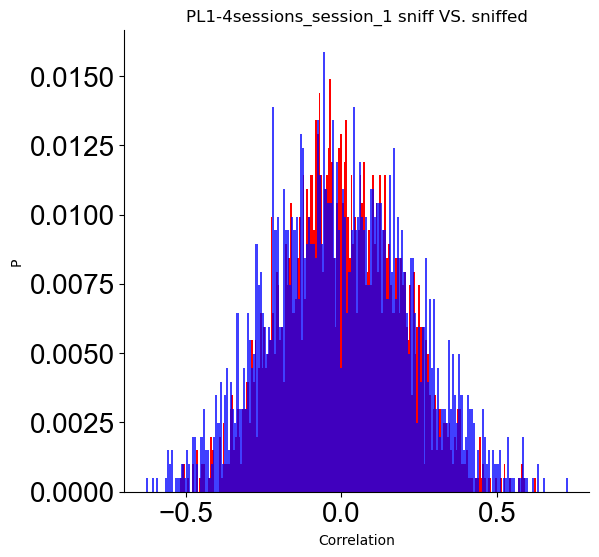

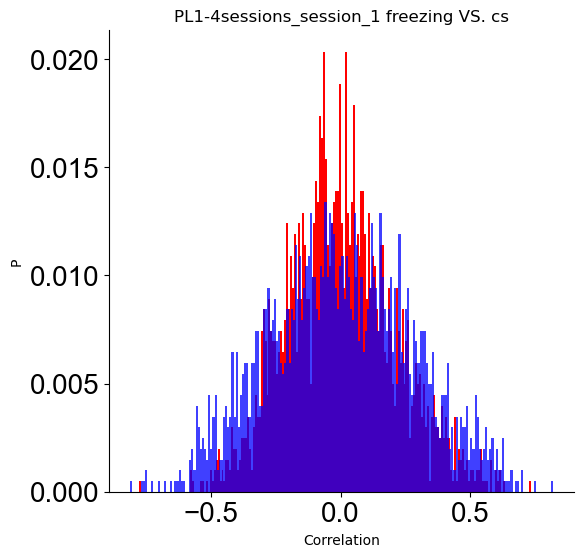

the shape of the dataframe in the status is: (6303, 64)
         Frame      C001      C002      C003      C004      C005      C006  \
0  178812.3580  0.933438  0.085719  2.192115 -0.903388 -1.787861  4.477706   
1  178812.4246  1.003095  1.015271  2.131349 -0.588765 -0.388555  3.881768   
2  178812.4913  0.289997  1.247313  0.748030 -0.591675  0.229606  3.933408   

       C008  C009      C011  ...      C099      C100      C102      C104  \
0  0.133668   0.0  0.655450  ... -2.777420  0.543280  1.730796  4.346797   
1  3.199056   0.0  0.865925  ... -2.817394  1.131764  1.817684  2.217870   
2  0.528910   0.0  0.284680  ... -1.228027  0.362778  0.802404  1.244073   

       C116      C124      C127      C130      C144      C149  
0 -0.768289  0.978130  0.301484 -1.385310 -1.572449 -0.151473  
1 -2.129771  1.366814  2.537292 -1.554587  1.315608 -0.095935  
2 -1.134599  0.959070  3.030958 -1.639484  2.101407 -0.752453  

[3 rows x 64 columns]
the shape of the dataframe in the status is: (3

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


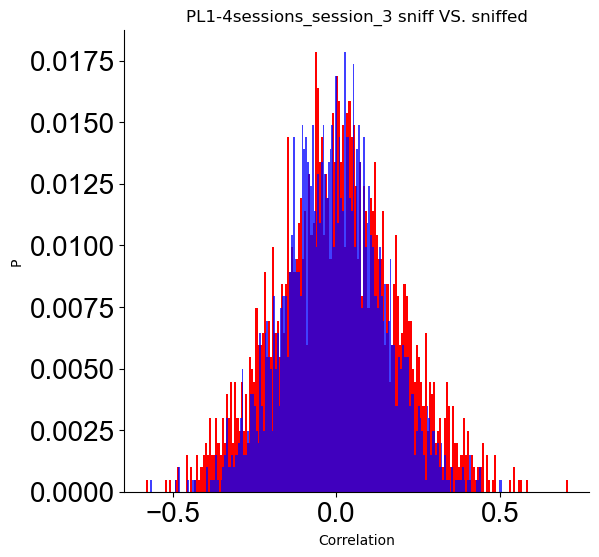

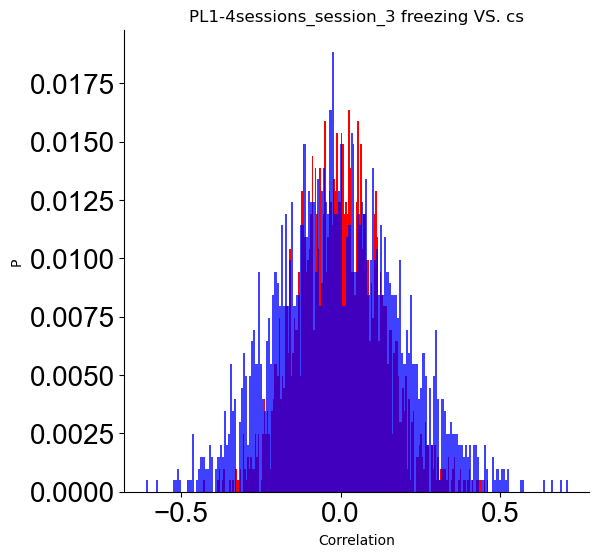

Processing PL2-4sessions
the shape of the dataframe in the status is: (9005, 68)
      Frame      C000      C001      C002      C005      C006      C007  \
0  0.000000  1.882352  2.126044  1.570884 -0.720866  3.289277  0.247879   
1  0.066627  2.150102  1.319309  1.514161  0.418964  2.818081  0.227991   
2  0.133254  1.670019  1.521481  1.601990  1.012005  2.169391 -0.157305   

       C008      C009      C010  ...      C139      C141      C144      C158  \
0  1.053450 -0.136153  2.495349  ...  2.531227 -0.041187 -0.138253  0.045598   
1  0.313135 -0.191499  1.758497  ...  1.589327  0.281624 -0.374681 -0.757263   
2  0.946621 -0.471562  1.580665  ...  1.412969 -0.148428 -0.456912 -0.103571   

       C166      C172  C181  C190  C191  C200  
0 -4.093380 -5.233209   0.0   0.0   0.0   0.0  
1 -3.294393 -4.606462   0.0   0.0   0.0   0.0  
2 -1.806186 -3.240040   0.0   0.0   0.0   0.0  

[3 rows x 68 columns]
the shape of the dataframe in the status is: (465, 68)
       Frame      C000     

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


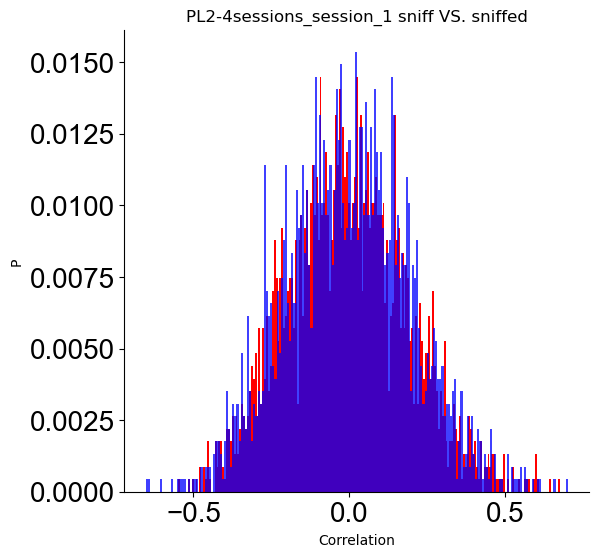

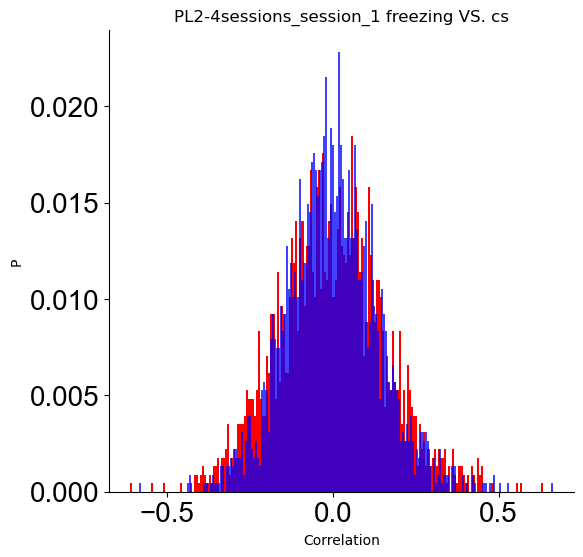

the shape of the dataframe in the status is: (6303, 68)
         Frame      C000      C001      C002      C005      C006      C007  \
0  178117.4750  2.780691  2.209171 -1.080403 -3.144904 -0.042337  0.147574   
1  178117.5416  2.744196  2.441762 -1.203381 -1.214345  0.202541 -0.440843   
2  178117.6083  1.378595  2.543779 -1.198714 -1.267939  0.659837 -0.045597   

       C008      C009      C010  ...      C139      C141      C144      C158  \
0 -3.200604 -0.794310  1.195013  ...  5.212932 -1.782774  2.872658 -1.108058   
1 -0.241700  0.089904  1.349117  ...  4.352812 -2.463667  2.378539  0.115327   
2 -0.976215 -0.151436  1.618292  ...  3.554479 -2.280672  1.957767  0.183450   

       C166      C172      C181      C190      C191      C200  
0  0.523469  4.854719  1.477329  0.571438 -2.073431  2.652256  
1  0.592749  3.883748  0.487638 -1.034800  0.590676  1.269807  
2 -0.037708  3.754957 -0.000608 -0.303816 -0.667447  2.248684  

[3 rows x 68 columns]
the shape of the dataframe in t

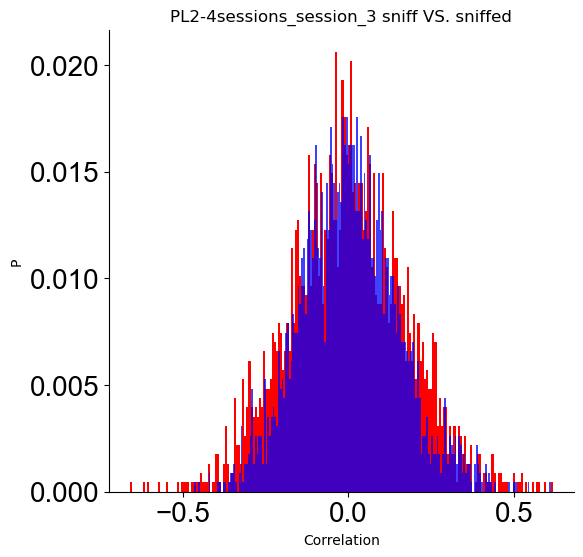

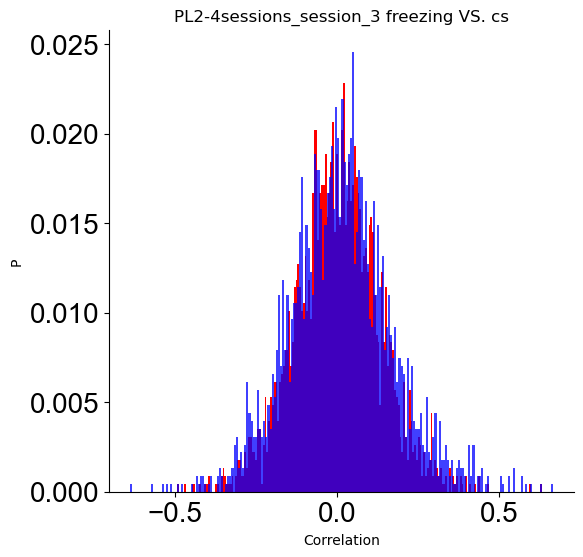

Processing PL4-4sessions
the shape of the dataframe in the status is: (9004, 69)
      Frame      C000      C001      C002      C003      C005      C006  \
0  0.000000  3.755609 -4.078836  1.843028  0.157964  0.764235 -1.170330   
1  0.066627  2.446564 -3.223034  1.581477  0.138686  0.340309 -1.523700   
2  0.133254  1.664416 -4.490755  1.694121  0.147763  0.886107 -1.359128   

       C009      C013      C014  ...      C132      C134      C135      C139  \
0  0.623585 -1.468013  0.662378  ...  0.582787  0.065301  3.014564 -1.341855   
1  1.026176 -0.735316  1.008011  ...  0.481637 -0.655678  3.342634 -0.072196   
2  1.632348 -1.330953  1.599828  ...  0.342890 -0.251258  2.939290 -1.226281   

       C143      C144      C145      C153      C165  C174  
0  1.157832  1.203096 -1.296453  0.425805  2.217723   0.0  
1  1.815349  1.368765 -1.153348 -0.018625  2.043756   0.0  
2  1.816488  1.726591 -0.833191  0.059762  1.844544   0.0  

[3 rows x 69 columns]
the shape of the dataframe in the 

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


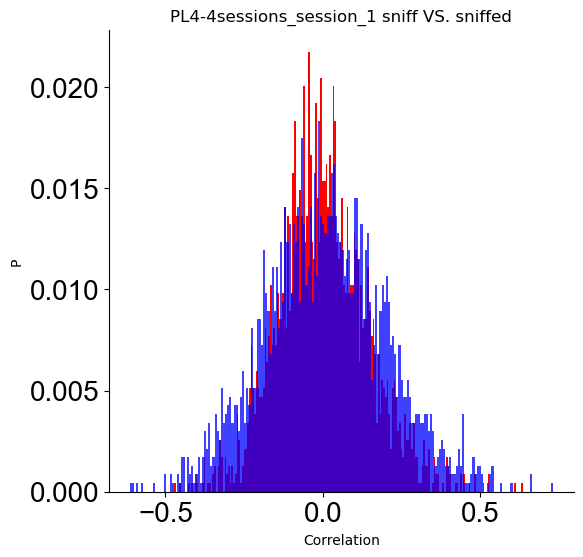

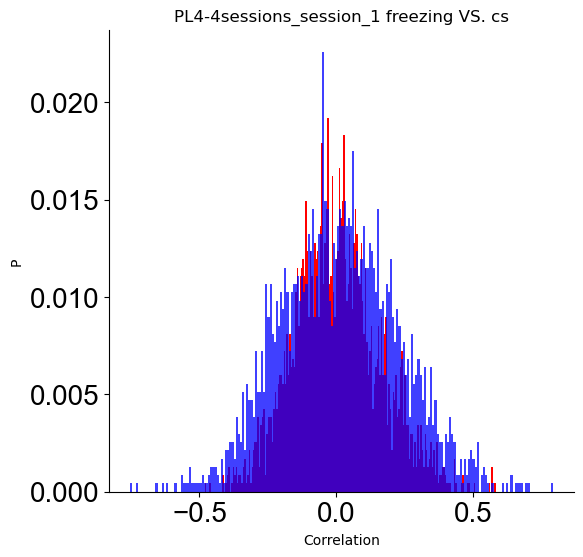

the shape of the dataframe in the status is: (6303, 69)
           Frame  C000      C001      C002      C003      C005      C006  \
0  255714.099000   0.0 -2.612643  1.822704  0.623110 -0.728871 -0.976381   
1  255714.165627   0.0 -0.627246  2.000600  1.439960  0.984047  0.431577   
2  255714.232254   0.0 -1.830645  3.122550  1.401215  0.829980  0.335760   

   C009      C013      C014  ...      C132      C134      C135      C139  \
0   0.0 -1.970157 -2.943198  ... -0.907035  2.250772  4.968257 -0.803539   
1   0.0 -0.428632 -1.035080  ... -0.737745  1.564287  4.628771  0.095639   
2   0.0 -0.553883 -1.016626  ... -1.157704  0.850754  5.132651  0.691047   

       C143      C144      C145      C153      C165      C174  
0 -0.913267  1.162866  0.435020 -1.525058 -2.792505  3.714197  
1 -1.008065  1.496956 -0.412194  0.171038 -0.399980  4.084443  
2 -1.057669  2.015953  0.157599 -0.060769 -0.141282  3.031008  

[3 rows x 69 columns]
the shape of the dataframe in the status is: (495, 69)


C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


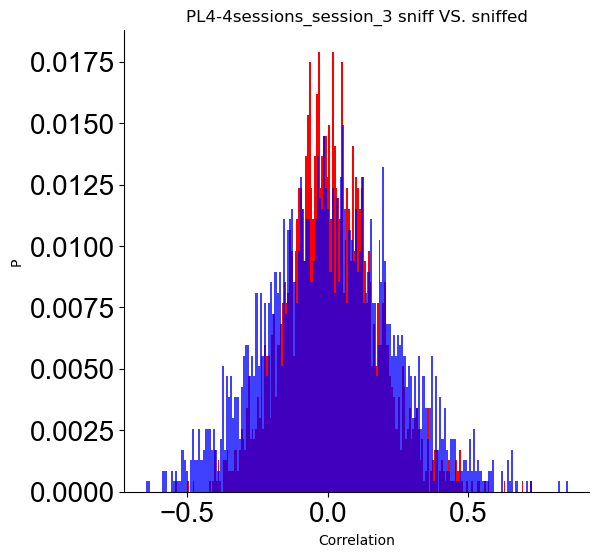

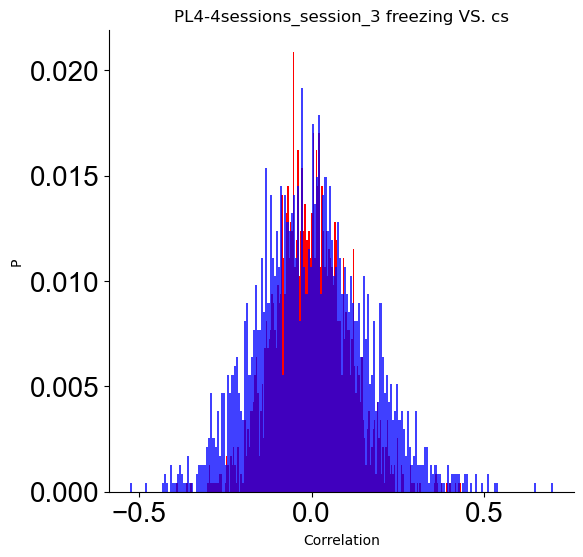

Processing PL5-4sessions
the shape of the dataframe in the status is: (9005, 52)
      Frame      C000      C001      C002      C003      C004      C005  \
0  0.000000  1.290402  2.294602 -1.748871 -1.423966 -0.184685 -0.940813   
1  0.066627  1.865450  1.888764 -1.196953 -1.450380 -0.415701 -0.570288   
2  0.133254  2.017927  1.618790 -1.116495 -0.176645 -0.580918  0.100148   

       C006      C007      C009  ...      C109      C117      C119      C128  \
0  0.287378 -0.128170 -1.097043  ...  1.993900  2.213281 -1.068773 -0.648819   
1  0.099064 -0.166335 -0.518960  ...  0.925882  2.251569 -1.094651 -1.084901   
2 -0.789346  0.422079  0.246706  ...  1.002228  2.253750 -1.330960 -0.887618   

       C131      C136  C148  C161  C184  C258  
0  3.430013  1.499972   0.0   0.0   0.0     0  
1  3.536361  1.745577   0.0   0.0   0.0     0  
2  2.663037  1.270036   0.0   0.0   0.0     0  

[3 rows x 52 columns]
the shape of the dataframe in the status is: (570, 52)
         Frame      C000   

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


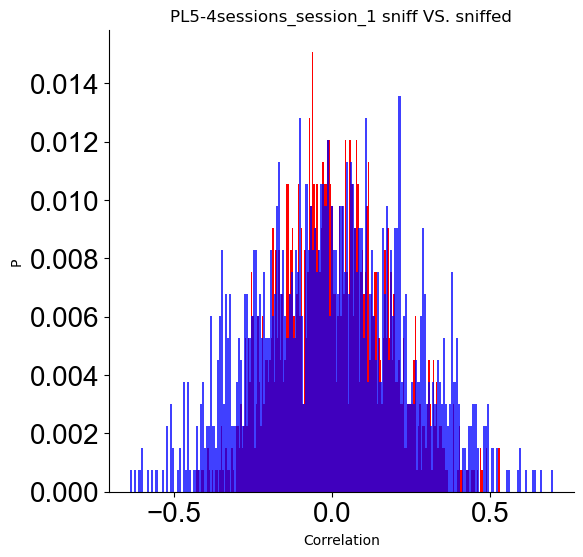

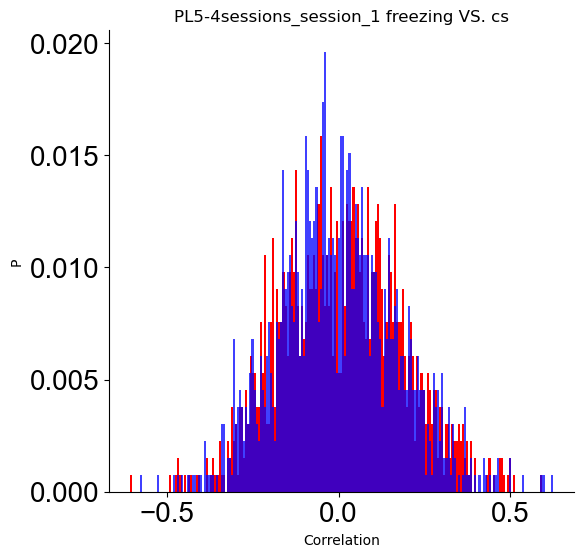

the shape of the dataframe in the status is: (6304, 52)
           Frame      C000      C001      C002  C003      C004  C005  C006  \
0  255233.048000 -1.403836 -1.344063 -0.082253     0  0.136082     0     0   
1  255233.114627 -0.799806 -0.819531 -0.995737     0  0.637204     0     0   
2  255233.181254 -0.760833 -1.521290 -0.615575     0  0.490298     0     0   

       C007      C009  ...      C109      C117      C119      C128      C131  \
0  0.543213  0.044803  ...  2.383697 -1.169121  0.673307 -1.133173 -0.500374   
1 -0.829985  0.799504  ...  0.689690 -0.545391 -0.606874 -1.837664  0.268225   
2 -0.540635  0.870529  ...  0.979025 -0.338756  0.845447 -0.995357 -0.101618   

       C136  C148      C161      C184  C258  
0  1.530813   0.0  0.097855  0.427420   0.0  
1  1.109007   0.0  0.436450  1.138694   0.0  
2  0.493811   0.0  0.348631  0.805399   0.0  

[3 rows x 52 columns]
the shape of the dataframe in the status is: (285, 52)
             Frame      C000      C001      C002

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


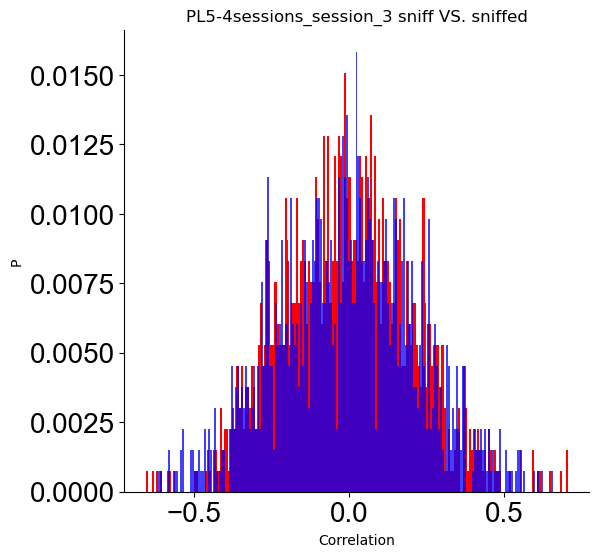

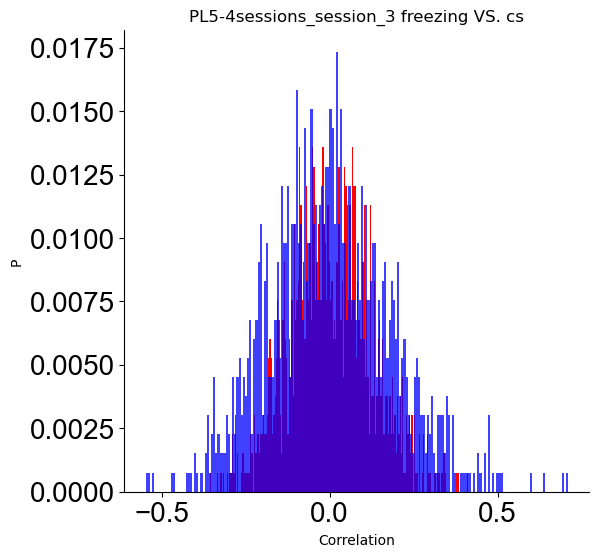

Processing PL6-4sessions
the shape of the dataframe in the status is: (9005, 57)
      Frame      C000      C001      C003      C004      C005      C007  \
0  0.000000 -1.438286  0.796251  0.957974  0.699171  2.907174  1.932964   
1  0.066627 -1.480634  0.639608  1.503675 -0.500378  2.683489  1.662719   
2  0.133254 -0.786086  0.153628  0.694080 -0.252688  2.186222  1.489885   

       C008      C009      C011  ...      C093      C095      C098      C102  \
0  0.697997 -0.915436  0.424050  ...  0.397270 -0.580281  0.166764 -0.092649   
1  1.044351 -0.605837 -0.121514  ... -0.227963  0.578406  0.293566  0.540894   
2  0.649603  0.577959  0.264686  ... -0.346553 -0.143735 -0.110104  0.344508   

       C103      C105      C109      C115  C116  C117  
0 -0.212614  2.263226 -0.619821  2.120015   0.0   0.0  
1 -0.709619  2.885304 -0.754232  1.463462   0.0   0.0  
2 -0.209482  1.502895 -1.299642  1.184088   0.0   0.0  

[3 rows x 57 columns]
the shape of the dataframe in the status is: (345,

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


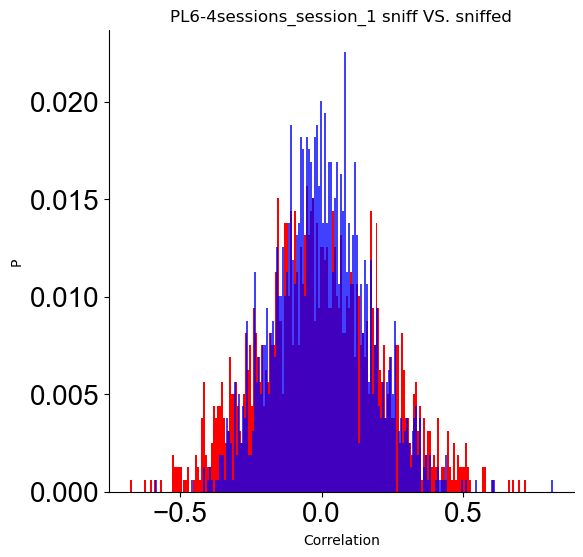

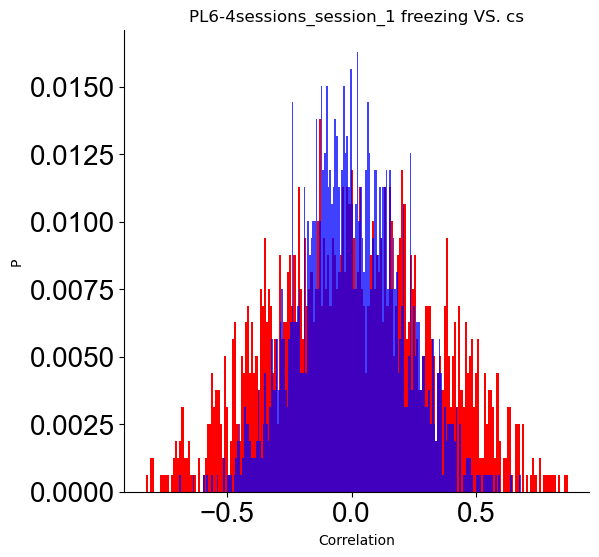

the shape of the dataframe in the status is: (6303, 57)
           Frame  C000      C001  C003      C004      C005      C007  \
0  255040.925000   0.0 -0.340415   0.0  0.558313  1.217489  1.237181   
1  255040.991627   0.0 -0.737405   0.0  0.363078  1.372034  3.226619   
2  255041.058254   0.0 -0.271991   0.0 -0.142899  1.398755  2.384367   

       C008      C009      C011  ...      C093      C095      C098      C102  \
0  0.011631  0.024000 -0.211640  ...  1.655138 -0.948930 -0.144956  1.570642   
1  0.321971  0.991499 -0.305215  ...  1.223567  0.152393  0.152147  1.819798   
2  0.420570 -0.029487 -0.122888  ...  1.103532  0.319155 -0.662931  1.588591   

       C103      C105      C109      C115      C116      C117  
0  1.289863 -0.851910 -1.600791 -1.758670  1.558811  1.121510  
1  0.048130  0.211200 -0.353218 -1.330814  0.088455  0.254986  
2  0.872968  0.334821  0.395657 -1.276696  0.334794 -0.008120  

[3 rows x 57 columns]
the shape of the dataframe in the status is: (375, 57)


C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


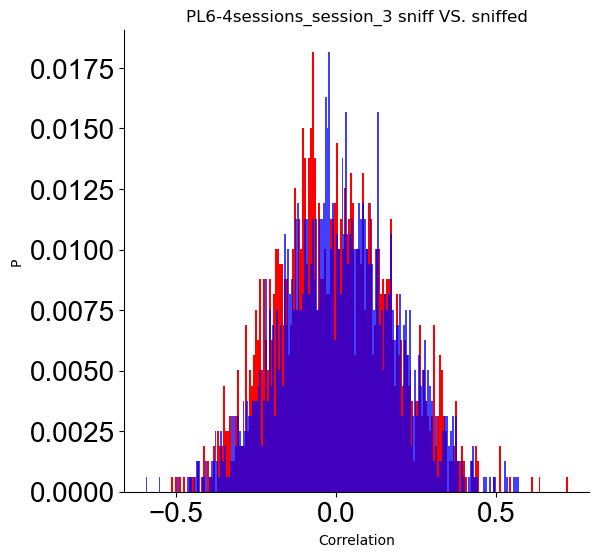

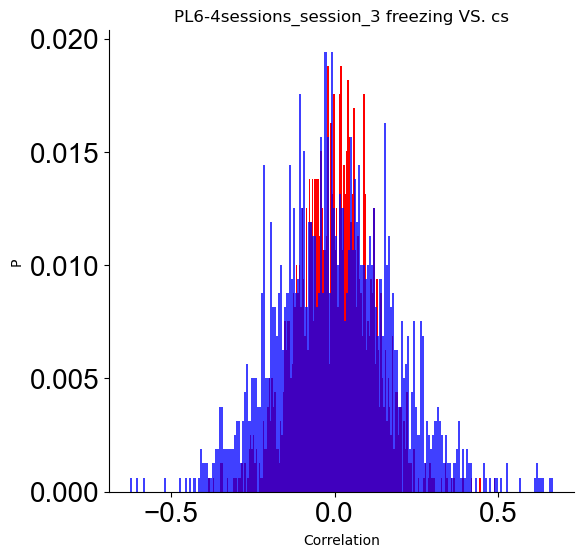

Processing PL7-4sessions
the shape of the dataframe in the status is: (9004, 103)
      Frame      C000      C001      C003      C004      C005      C006  \
0  0.000000 -0.417384  0.315406  1.123680 -2.203288 -1.800385 -1.499902   
1  0.066627 -0.191973  1.530964  0.740612 -0.886683 -0.233298  0.005012   
2  0.133254 -0.355571  1.060271  0.108478 -0.490671 -1.355528  0.121047   

       C007      C008      C010  ...      C150      C152      C154      C156  \
0  0.046575 -0.365860 -1.159456  ... -0.770387  0.831462  2.104780 -0.677344   
1 -0.292471  0.444902 -1.581338  ...  0.386441  2.061403  0.991162 -1.336977   
2 -0.122246  0.373422 -0.672107  ...  0.732239  1.580555  0.659669 -1.318021   

       C163      C164      C166  C167  C168  C181  
0  0.410532  0.409700 -3.923991   0.0   0.0   0.0  
1 -0.222612  0.231293 -2.017126   0.0   0.0   0.0  
2  0.129467  0.246321 -2.227694   0.0   0.0   0.0  

[3 rows x 103 columns]
the shape of the dataframe in the status is: (330, 103)
        

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


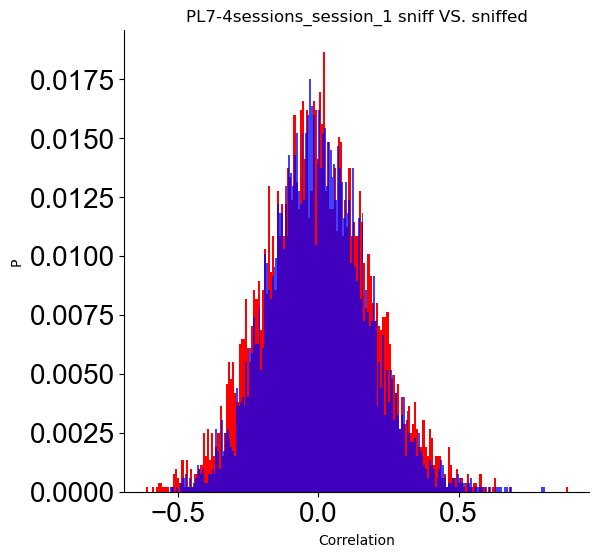

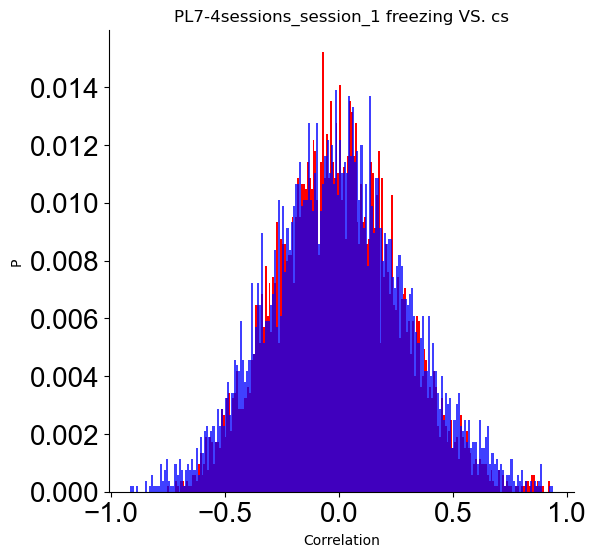

the shape of the dataframe in the status is: (6303, 103)
           Frame      C000  C001  C003      C004      C005      C006  \
0  254928.101000 -1.039101   0.0   0.0  3.616357 -1.701546 -0.626205   
1  254928.167627  0.502057   0.0   0.0  0.288052  1.861888  0.251687   
2  254928.234254 -0.836521   0.0   0.0  0.177671 -0.623127  0.668754   

       C007      C008  C010  ...      C150      C152      C154      C156  \
0  0.000560  0.353621   0.0  ...  1.258408  3.190549  5.540622 -2.294352   
1 -1.018181 -0.776160   0.0  ...  0.108242  4.865530  2.753191 -0.237908   
2  0.007998 -0.892023   0.0  ... -0.066970  4.390695  4.298503 -0.188512   

       C163      C164      C166  C167      C168      C181  
0  1.535702 -1.068518 -1.736712   0.0  1.320043  0.842161  
1  0.662850  0.518766 -0.442191   0.0  0.750101  0.128799  
2  1.059393 -0.231990 -1.677617   0.0  0.573119  0.046719  

[3 rows x 103 columns]
the shape of the dataframe in the status is: (210, 103)
             Frame      C000 

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


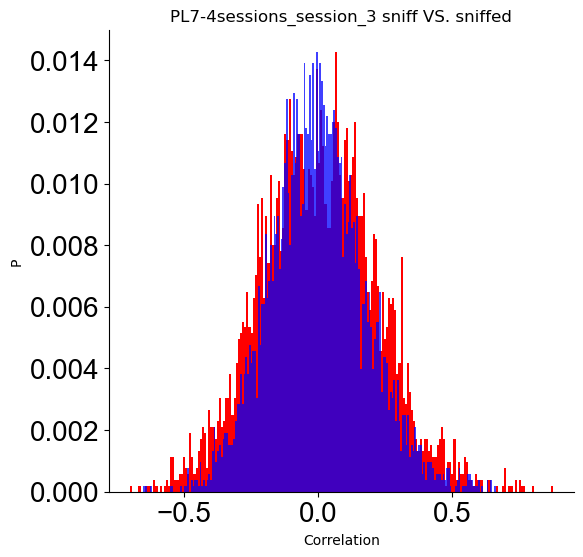

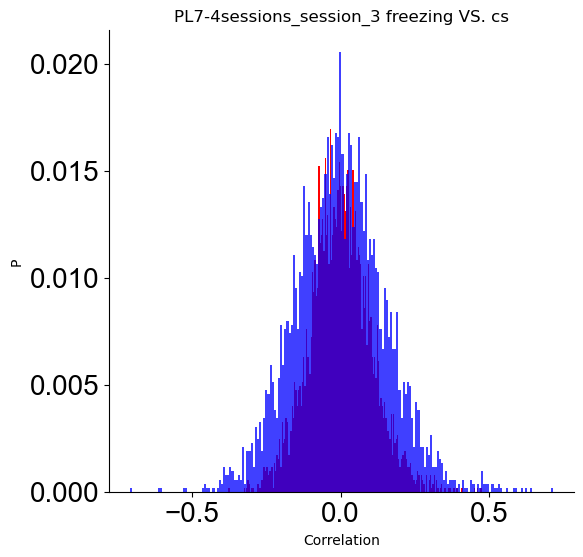

Processing PL8-4sessions
the shape of the dataframe in the status is: (9004, 89)
      Frame      C000      C001      C002      C003      C004      C006  \
0  0.000000  1.921747  4.152903  2.861012  0.097169  0.263733  0.249607   
1  0.066627  1.862422  3.958709  2.934099  1.632315  0.799693  0.295830   
2  0.133254  0.664600  3.506486  1.501934  2.543193 -0.158093 -0.348105   

       C007      C008      C009  ...      C137      C139      C142      C143  \
0 -0.517445  0.775824  3.158980  ... -2.385729 -1.200805  0.407488 -1.057894   
1 -0.623647 -0.024468  2.568319  ... -1.688854 -1.416128  0.838947 -0.392344   
2 -0.009673  0.097926  2.559039  ... -2.103004 -1.397658  0.600798 -1.436075   

       C144      C147      C152  C155  C157  C162  
0  0.477477  0.380578  2.416079   0.0   0.0   0.0  
1  1.090083  0.075393  1.048121   0.0   0.0   0.0  
2  1.293684  0.254273  1.002126   0.0   0.0   0.0  

[3 rows x 89 columns]
the shape of the dataframe in the status is: (1562, 89)
        Fr

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


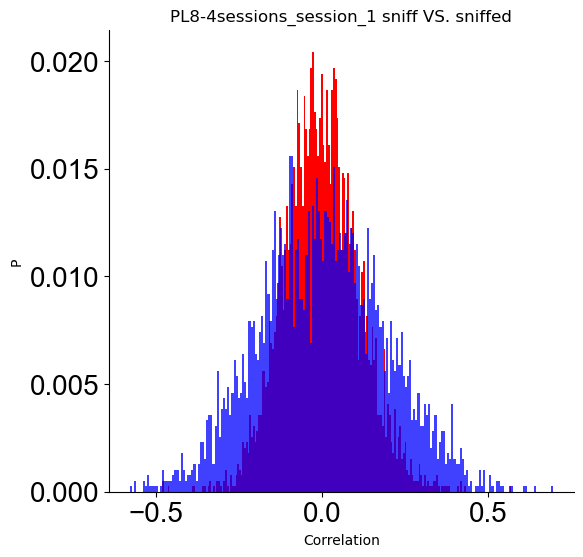

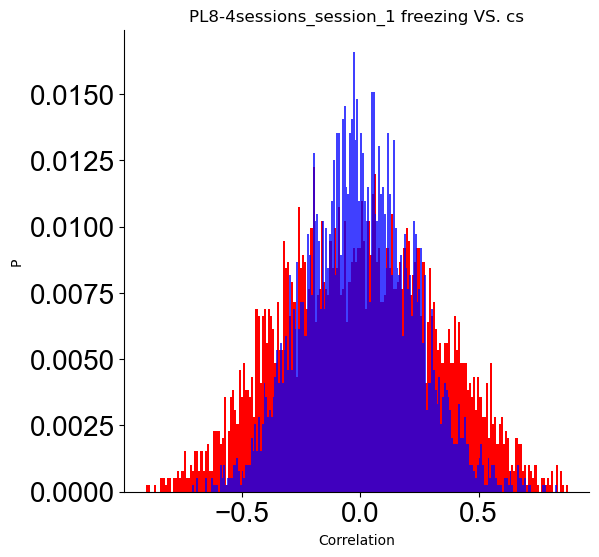

the shape of the dataframe in the status is: (6302, 89)
           Frame      C000      C001  C002      C003  C004  C006      C007  \
0  254856.044000  1.331911  1.792388   0.0  3.809549   0.0   0.0  2.600841   
1  254856.110627  0.550712  1.754235   0.0  0.855666   0.0   0.0  1.469867   
2  254856.177254 -0.199381  0.613928   0.0  1.754661   0.0   0.0 -0.114421   

       C008      C009  ...      C137      C139      C142  C143      C144  \
0 -0.596678  0.155438  ...  0.465159 -0.585110  0.685006   0.0  2.091528   
1 -0.112452  0.643337  ... -0.982536 -1.063970  0.879485   0.0  3.146675   
2 -0.968557  0.499282  ... -2.585601 -1.670126 -0.234377   0.0  2.269377   

       C147  C152      C155      C157      C162  
0  4.387153   0.0  6.292781 -1.628153  3.273445  
1  6.414867   0.0  6.463041 -1.730355  2.974453  
2  2.959557   0.0  5.984429 -0.704229  1.484737  

[3 rows x 89 columns]
the shape of the dataframe in the status is: (555, 89)
             Frame      C000      C001  C002    

C:\Users\DELL\AppData\Local\Temp\ipykernel_936\438371102.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性


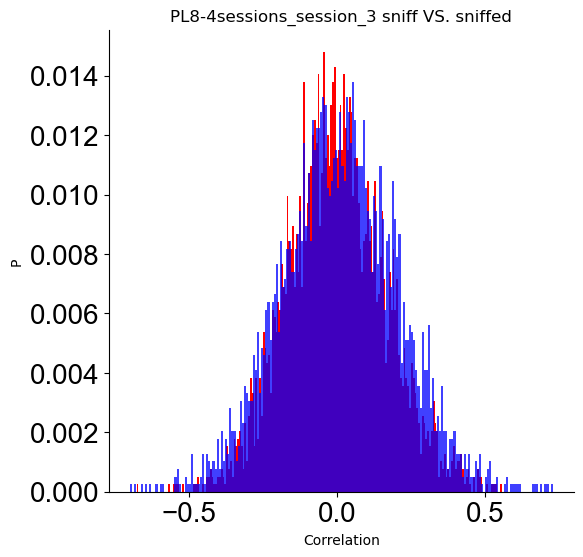

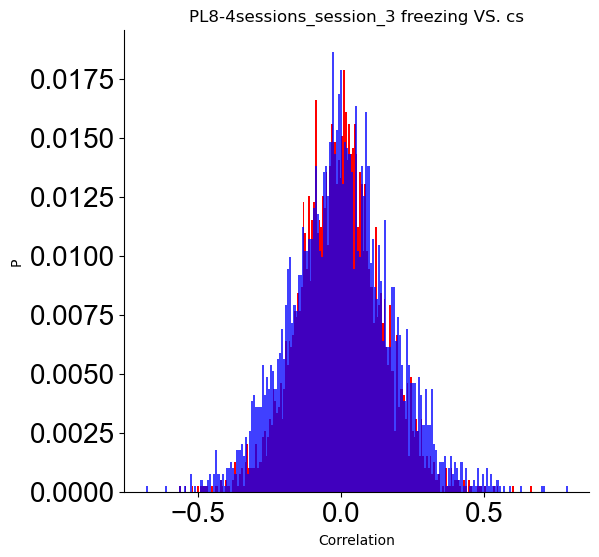

PermissionError: [Errno 13] Permission denied: 'F:/AAA-RXC/Results/FWHM/FWHM_new.csv'

In [12]:
print('IL')

mice_FWHM_list = []

#whole_1_chain = []
In_all_1_chain = []
sniff_1_chain = []
sniffed_1_chain = []
freezing_1_chain = []
cs_1_chain = []

#whole_2_chain = []
In_all_2_chain = []
sniff_2_chain = []
sniffed_2_chain = []
freezing_2_chain = []
cs_2_chain = []

#whole_3_chain = []
In_all_3_chain = []
sniff_3_chain = []
sniffed_3_chain = []
freezing_3_chain = []
cs_3_chain = []
  
#whole_4_chain = []
In_all_4_chain = []
sniff_4_chain = []
sniffed_4_chain = []
freezing_4_chain = []
cs_4_chain = []


for i in range(len(mice_list)):
    
    mouse_name = mice_list[i]
    mouseSummary = mice_list[i]
   
    
    print('Processing', mouse_name)
    
    #mice = os.path.join(root_path, mouse_name)
    #trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    #event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx_process.xlsx")
    #event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx_process.xlsx")
    #event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx_process.xlsx")

    
    # 选择FPS
    if mouse_name.split('_')[0] in ['PL1-4sessions',]:
        fps = 15
    else:
        fps = 15
        
    #dfLabeled, session_1, session_2, session_3 = add_event_label(trace, event1, event2, event3)
    #session_list = [session_1, session_2, session_3]
    sessionName_list = ['session_1', 'session_2', 'session_3', 'session_4']
    
    
    #for session_index in range(len(sessionName_list)):
    for sessionID in session_ids:
            
            
            event = os.path.join(data_path, mouseSummary, f"event{sessionID}.xlsx")
            session = pd.read_csv(os.path.join(data_path, mouseSummary, f"session_{sessionID}_trace.csv"))
            #session = session_list[session_index]
            sessionName = sessionName_list[sessionID-1]
            

            
            #whole_df = session.drop('Frame_Label', axis=1)  
            In_all_df = check_frame_interval(session, 'In_all')
            sniff_df = check_frame_interval(session, 'sniff')           ### RT1 and RET do not use this line
            sniffed_df = check_frame_interval(session, 'sniffed')       ### RT1 and RET do not use this line
            freezing_df = check_frame_interval(session, 'freezing')   
            cs_df = check_frame_interval(session, 'cs') 


            #whole_corrs = corr_list(whole_df)
            In_all_corrs = corr_list(In_all_df)
            sniff_corrs = corr_list(sniff_df)         ### RT1 and RET do not use this line
            sniffed_corrs = corr_list(sniffed_df)     ### RT1 and RET do not use this line
            freezing_corrs = corr_list(freezing_df)
            cs_corrs = corr_list(cs_df)


            # loop and update chain
            if sessionName == 'session_1':
                #whole_1_chain = itertools.chain(whole_1_chain,whole_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
                sniff_1_chain = itertools.chain(sniff_1_chain,sniff_corrs)
                sniffed_1_chain = itertools.chain(sniffed_1_chain,sniffed_corrs)
                freezing_1_chain = itertools.chain(freezing_1_chain,freezing_corrs)
                cs_1_chain = itertools.chain(cs_1_chain,cs_corrs)
            elif sessionName == 'session_2':
                #whole_2_chain = itertools.chain(whole_2_chain,whole_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
                sniff_2_chain = itertools.chain(sniff_2_chain,sniff_corrs)
                sniffed_2_chain = itertools.chain(sniffed_2_chain,sniffed_corrs)
                freezing_2_chain = itertools.chain(freezing_2_chain,freezing_corrs)
                cs_2_chain = itertools.chain(cs_2_chain,cs_corrs)
            elif sessionName == 'session_3':
                #whole_3_chain = itertools.chain(whole_3_chain,whole_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
                sniff_3_chain = itertools.chain(sniff_3_chain,sniff_corrs)
                sniffed_3_chain = itertools.chain(sniffed_3_chain,sniffed_corrs)
                freezing_3_chain = itertools.chain(freezing_3_chain,freezing_corrs)
                cs_3_chain = itertools.chain(cs_3_chain,cs_corrs)
            else :
                #whole_4_chain = itertools.chain(whole_4_chain,whole_corrs)
                In_all_4_chain = itertools.chain(In_all_4_chain,In_all_corrs)
                sniff_4_chain = itertools.chain(sniff_4_chain,sniff_corrs)
                sniffed_4_chain = itertools.chain(sniffed_4_chain,sniffed_corrs)
                freezing_4_chain = itertools.chain(freezing_4_chain,freezing_corrs)
                cs_4_chain = itertools.chain(cs_4_chain,cs_corrs)
        
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" sniff VS. sniffed"
            overlaid_histogram(figsize, sniff_corrs, sniffed_corrs, n_bins = 200, 
                            data1_name="sniff", data1_color="red", 
                            data2_name="sniffed", data2_color="blue") # 在这里改颜色
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'F:/AAA-RXC/Results/FWHM/{title}.png')  # 保存图像 C:\Users\DELL\Desktop\pl14new
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" freezing VS. cs"
            overlaid_histogram(figsize,freezing_corrs, cs_corrs, n_bins = 200, 
                            data1_name="freezing/exploration", data1_color="red", 
                            data2_name="cs/SI", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'F:/AAA-RXC/Results/FWHM/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        #'whole FWHM':FWHM(whole_corrs),
                        'In_all FWHM':FWHM(In_all_corrs),
                        'sniff FWHM':FWHM(sniff_corrs),
                        'sniffed FWHM':FWHM(sniffed_corrs),
                        'freezing/exploration FWHM':FWHM(freezing_corrs),
                        'cs/SI FWHM':FWHM(cs_corrs)}
            mice_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            mice_FWHM_list.append(mice_FWHM)

mice_FWHM_DF = pd.concat(mice_FWHM_list)
mice_FWHM_DF.to_csv('F:/AAA-RXC/Results/FWHM/FWHM_new.csv')


# FWHM for all mice

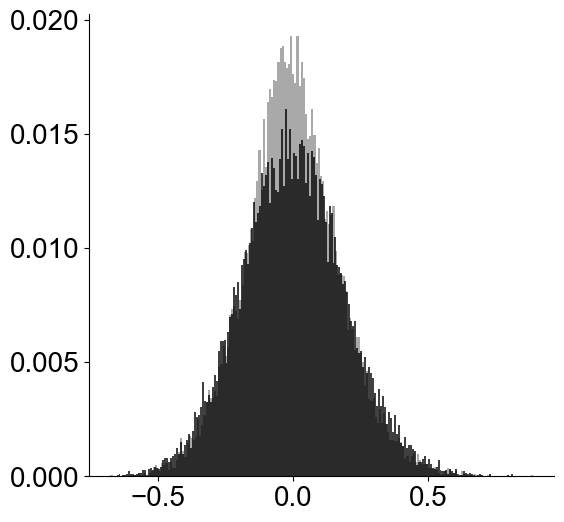

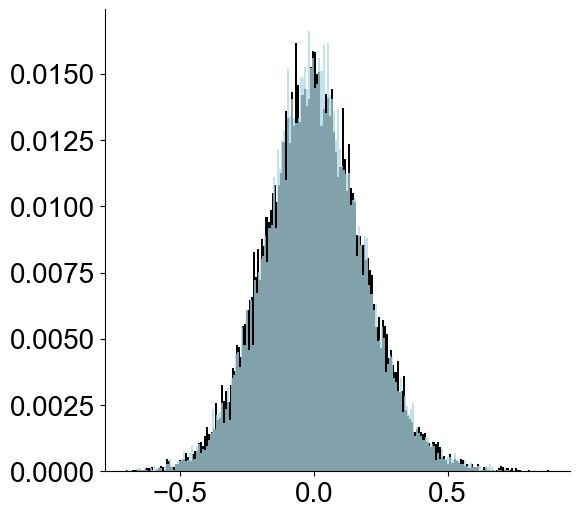

In [ ]:
sniff_1_list = list(sniff_1_chain)
sniffed_1_list = list(sniffed_1_chain)
freezing_1_list = list(freezing_1_chain)
cs_1_list = list(cs_1_chain)
#In_all_1_chain = []

#freezing_2_list = list(freezing_2_chain)
#cs_2_list = list(cs_2_chain)
#In_right_2_chain = []
#In_left_2_chain = []
#In_all_2_chain = []

sniff_3_list = list(sniff_3_chain)
sniffed_3_list = list(sniffed_3_chain)
freezing_3_list = list(freezing_3_chain)
cs_3_list = list(cs_3_chain)
#In_all_3_chain = []

#freezing_4_list = list(freezing_4_chain)
#cs_4_list = list(cs_4_chain)


figsize = (6,6)
overlaid_histogram(figsize,sniff_1_list, sniffed_1_list, n_bins = 200, 
                   data1_name="WT_Object", data1_color="darkgray", 
                   data2_name="WT_Social", data2_color="black", 
                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
                   title="habituation WT OBJECTvsSOCIAL")

overlaid_histogram(figsize,freezing_1_list, cs_1_list, n_bins = 200, 
                   data1_name="WT_Object", data1_color="black", 
                   data2_name="WT_Social", data2_color="darkgray", 
                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
                   title="session 1 WT OBJECTvsSOCIAL")

overlaid_histogram(figsize, sniff_3_list, sniffed_3_list, n_bins = 200, 
                   data1_name="WT_Object", data1_color="black", 
                   data2_name="WT_Social", data2_color="lightblue", 
                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
                   title="session 2 WT OBJECTvsSOCIAL")

overlaid_histogram(figsize, freezing_3_list, cs_3_list, n_bins = 200, 
                   data1_name="WT_Object", data1_color="black", 
                   data2_name="WT_Social", data2_color="lightblue", 
                   x_label="Pearson Correlation Coefficient Distribution", y_label="Probability",
                   title="session 2 WT OBJECTvsSOCIAL")

allFWHM_dic = {'mouseType':'WT',
            'whichSession':'session 1',
            'sniff FWHM':FWHM(sniff_1_list),
            'sniffed FWHM':FWHM(sniffed_1_list),
            'whichSession':'session 2',
            'freezing FWHM':FWHM(freezing_2_list),
            'cs FWHM':FWHM(cs_2_list),
            'whichSession':'session 3',
            'sniff FWHM':FWHM(sniff_3_list),
            'sniffed FWHM':FWHM(sniffed_3_list)
            'whichSession':'session 4',
            'freezing FWHM':FWHM(freezing_4_list),
            'cs FWHM':FWHM(cs_4_list)}
            
WT_FWHM_All = pd.DataFrame.from_dict(allFWHM_dic, orient='index').T
WT_FWHM_All.to_csv('F:/AAA-RXC/Results/FWHM/FWHM_All_mice.csv')

# PL2，3个session

In [ ]:
root_path = 'E:/山东第一医科大学/New Data/PL2/Social'
PL2_list = ['1-PL2-SOCIAL','3-PL2-SOCIAL', '7-PL2-SOCIAL', '14-PL2-SOCIAL', '21-PL2-SOCIAL',]

In [ ]:
print('PL2')

PL2_FWHM_list = []

Investigating_RIGHT_SNIFF_1_chain = []
Investigating_LEFT_SNIFF_1_chain = []
In_right_1_chain = []
In_left_1_chain = []
In_all_1_chain = []
Investigating_RIGHT_SNIFF_2_chain = []
Investigating_LEFT_SNIFF_2_chain = []
In_right_2_chain = []
In_left_2_chain = []
In_all_2_chain = []
Investigating_RIGHT_SNIFF_3_chain = []
Investigating_LEFT_SNIFF_3_chain = []
In_right_3_chain = []
In_left_3_chain = []
In_all_3_chain = []


for i in range(len(PL2_list)):
    
    mouse_name = PL2_list[i]
    
    print('Processing', mouse_name)
    
    mice = os.path.join(root_path, mouse_name)
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx")
    event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx")
    event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx")

    
    # 选择FPS
    if mouse_name.split('_')[0] in ['1-PL2-SOCIAL','3-PL2-SOCIAL', '7-PL2-SOCIAL', '14-PL2-SOCIAL', '21-PL2-SOCIAL',]:
        fps = 15
    else:
        fps = 20
        
    dfLabeled, session_1, session_2, session_3 = add_event_label(trace, event1, event2, event3)
    session_list = [session_1, session_2, session_3]
    sessionName_list = ['session_1', 'session_2', 'session_3']
    
    for session_index in range(len(sessionName_list)):
            
            session = session_list[session_index]
            sessionName = sessionName_list[session_index]
            
            Investigating_RIGHT_SNIFF_df = check_frame_interval(session, 'Investigating_RIGHT_SNIFF')
            Investigating_LEFT_SNIFF_df = check_frame_interval(session, 'Investigating_LEFT_SNIFF') 
            In_right_df = check_frame_interval(session, 'In_right')
            In_left_df = check_frame_interval(session, 'In_left')
            In_all_df = check_frame_interval(session, 'In_all')
            
            Investigating_RIGHT_SNIFF_corrs = corr_list(Investigating_RIGHT_SNIFF_df)
            Investigating_LEFT_SNIFF_corrs = corr_list(Investigating_LEFT_SNIFF_df)
            In_right_corrs = corr_list(In_right_df)
            In_left_corrs = corr_list(In_left_df)
            In_all_corrs = corr_list(In_all_df)


            # loop and update chain
            if sessionName == 'session_1':
                Investigating_RIGHT_SNIFF_1_chain = itertools.chain(Investigating_RIGHT_SNIFF_1_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_1_chain = itertools.chain(Investigating_LEFT_SNIFF_1_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_1_chain = itertools.chain(In_right_1_chain,In_right_corrs)
                In_left_1_chain = itertools.chain(In_left_1_chain,In_left_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
            elif sessionName == 'session_2':
                Investigating_RIGHT_SNIFF_2_chain = itertools.chain(Investigating_RIGHT_SNIFF_2_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_2_chain = itertools.chain(Investigating_LEFT_SNIFF_2_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_2_chain = itertools.chain(In_right_2_chain,In_right_corrs)
                In_left_2_chain = itertools.chain(In_left_2_chain,In_left_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
            else :
                Investigating_RIGHT_SNIFF_3_chain = itertools.chain(Investigating_RIGHT_SNIFF_3_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_3_chain = itertools.chain(Investigating_LEFT_SNIFF_3_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_3_chain = itertools.chain(In_right_3_chain,In_right_corrs)
                In_left_3_chain = itertools.chain(In_left_3_chain,In_left_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
        
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" Investigating_RIGHT_SNIFF VS. Investigating_LEFT_SNIFF"
            overlaid_histogram(figsize,Investigating_RIGHT_SNIFF_corrs, Investigating_LEFT_SNIFF_corrs, n_bins = 200, 
                            data1_name="PL2_Investigating_RIGHT_SNIFF", data1_color="red", 
                            data2_name="PL2_Investigating_LEFT_SNIFF", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer2/{title}.png')  # 保存图像
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+"  In_Right VS. In_Left"
            overlaid_histogram(figsize,In_right_corrs, In_left_corrs, n_bins = 200, 
                            data1_name="PL2_In_Right", data1_color="red", 
                            data2_name="PL2_In_Left", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer2/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        'Investigating_RIGHT_SNIFF FWHM':FWHM(Investigating_RIGHT_SNIFF_corrs),
                        'Investigating_LEFT_SNIFF FWHM':FWHM(Investigating_LEFT_SNIFF_corrs),
                        'In_right FWHM':FWHM(In_right_corrs),
                        'In_left FWHM':FWHM(In_left_corrs),
                        'In_all FWHM':FWHM(In_all_corrs)}
            PL2_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            PL2_FWHM_list.append(PL2_FWHM)

PL2_FWHM_DF = pd.concat(PL2_FWHM_list)
PL2_FWHM_DF.to_csv('C:/Users/卡塔利纳的杰克巴尔多/Desktop/PL2_FWHM.csv')

PL2
Processing 1-PL2-SOCIAL


FileNotFoundError: [Errno 2] No such file or directory: 'E:/山东第一医科大学/New Data/PL2/Social\\1-PL2-SOCIAL\\TRACE_Con.csv'

# 4个Session特殊情况
修改了部分函数，适应4个session的特殊情况

In [ ]:
# 定义函数
# 分离不同的session。根据TRACE文件中的'time'列中的值，将不同的session区分开。

def separate_session(df):
    df = pd.read_csv(df, index_col=0)
    df_copy = df.copy()
    df_copy['index_col'] = pd.to_numeric(df_copy.index, errors='coerce')
    check_point = []
    frame_list = df_copy['index_col'].values.tolist()

    for i in range(len(df_copy)):
        if i < len(df_copy) - 1:
            if (frame_list[i+1] - frame_list[i]) > 3:
                check_point.append(frame_list[i+1])

    # 根据分割点拆分为4个子DataFrame
    df_1 = df_copy[df_copy['index_col'] < check_point[0]]
    df_2 = df_copy[(df_copy['index_col'] < check_point[1]) & (df_copy['index_col'] >= check_point[0])]
    df_3 = df_copy[(df_copy['index_col'] < check_point[2]) & (df_copy['index_col'] >= check_point[1])]
    df_4 = df_copy[df_copy['index_col'] >= check_point[2]]
    
    # 删除索引列
    df_1.drop(columns='index_col', inplace=True)
    df_2.drop(columns='index_col', inplace=True)
    df_3.drop(columns='index_col', inplace=True)
    df_4.drop(columns='index_col', inplace=True)
    
    return df_1, df_2, df_3, df_4
# 处理分离后的session文件，使每个session的时间是从0开始
def process_frame(df):
    # 获取DataFrame的index并转换为float类型的list
    index_list = [float(index) for index in df.index]

    # 判断第一个index的值是否为0，并进行相应处理
    if index_list[0] != 0:
        # 如果第一个index的值不为0，将所有index值减去第一个index值，以实现“相对于第一个index的增量”效果
        index_list = [index - index_list[0] for index in index_list]

    return index_list

def process_event_interval(df):
    # 从DataFrame中提取'From Second'和'To Second'列，并转换为二维列表
    event_list = df[['From Second', 'To Second']].values.tolist()

    # 返回处理后的新事件列表
    return event_list


# get enevt label for an event file based on different mice and session
# for each session, we have separate event file
# 获得事件标记
def get_event_label(event_df_1, event_df_2, event_df_3, event_df_4):
    event_label_mapping = {
        'Investigating_right_sniff': 11,
        'Investigating_left_sniff': 12,
        'In_right': 21,
        'In_all': 22,
        'In_left': 23
    }
    
    event_label_lists = [[], [], [], []]

    event_dfs = [event_df_1, event_df_2, event_df_3, event_df_4]
    
    for i, event_df in enumerate(event_dfs):
        event_status = event_df['Event'].values.tolist()
        event_label_list = event_label_lists[i]
        
        for event in event_status:
            if event in event_label_mapping:
                event_label_list.append(event_label_mapping[event])
    
    return tuple(event_label_lists)



def add_event_label(trace_df, event_1_path, event_2_path, event_3_path, event_4_path):
    # get separate sessions
    df_1, df_2, df_3, df_4 = separate_session(trace_df)

    # get df1, df2, df3, df4 frame time list
    frame_list_1 = process_frame(df_1)
    frame_list_2 = process_frame(df_2)
    frame_list_3 = process_frame(df_3)
    frame_list_4 = process_frame(df_4)

    # get event dataframes
    event_df_1 = pd.read_excel(event_1_path)
    event_df_2 = pd.read_excel(event_2_path)
    event_df_3 = pd.read_excel(event_3_path)
    event_df_4 = pd.read_excel(event_4_path)
    # get event intervals
    interval_list_1 = process_event_interval(event_df_1)
    interval_list_2 = process_event_interval(event_df_2)
    interval_list_3 = process_event_interval(event_df_3)
    interval_list_4 = process_event_interval(event_df_4)
    # get event labels
    event_label_1, event_label_2, event_label_3, event_label_4 = get_event_label(event_df_1, event_df_2, event_df_3, event_df_4)

    # deal with session 1
    frame_label_list_1 = []
    for frame in frame_list_1:
        frame_label = str()
        if frame > 5:
            for i in range(len(interval_list_1)):
                if min(interval_list_1[i]) <= frame <= max(interval_list_1[i]):
                    frame_label = frame_label + str(event_label_1[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_1.append(frame_label)

    new_df_1 = df_1.copy()
    new_df_1['Frame_Label'] = frame_label_list_1
    new_df_1 = new_df_1.dropna()

    # deal with session 2
    frame_label_list_2 = []
    for frame in frame_list_2:
        frame_label = str()
        for i in range(len(interval_list_2)):
            if min(interval_list_2[i]) < frame < max(interval_list_2[i]):
                frame_label = frame_label + str(event_label_2[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_2.append(frame_label)

    new_df_2 = df_2.copy()
    new_df_2['Frame_Label'] = frame_label_list_2
    new_df_2 = new_df_2.dropna()

    # deal with session 3
    frame_label_list_3 = []
    for frame in frame_list_3:
        frame_label = str()
        for i in range(len(interval_list_3)):
            if min(interval_list_3[i]) < frame < max(interval_list_3[i]):
                frame_label = frame_label + str(event_label_3[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_3.append(frame_label)

    new_df_3 = df_3.copy()
    new_df_3['Frame_Label'] = frame_label_list_3
    new_df_3 = new_df_3.dropna()

    # deal with session 4
    frame_label_list_4 = []
    for frame in frame_list_4:
        frame_label = str()
        for i in range(len(interval_list_4)):
            if min(interval_list_4[i]) < frame < max(interval_list_4[i]):
                frame_label = frame_label + str(event_label_4[i])

        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        frame_label_list_4.append(frame_label)

    new_df_4 = df_4.copy()
    new_df_4['Frame_Label'] = frame_label_list_4
    new_df_4 = new_df_4.dropna()

    frames = [new_df_1, new_df_2, new_df_3, new_df_4]
    new_df = pd.concat(frames)

    print('The df shape of session 1:', new_df_1.shape)
    print('The df shape of session 2:', new_df_2.shape)
    print('The df shape of session 3:', new_df_3.shape)
    print('The df shape of session 4:', new_df_4.shape)
    print(' ')

    return new_df, new_df_1, new_df_2, new_df_3, new_df_4

In [ ]:
# 检查特定状态下的帧间隔，并返回满足条件的数据子集
def check_frame_interval(df, which_status_to_check_frame):
    
    # set up which_status_to_check_frame
    
    if which_status_to_check_frame == 'Investigating_RIGHT_SNIFF':
        which_status_to_check_frame = str(11)
    elif which_status_to_check_frame == 'Investigating_LEFT_SNIFF':
        which_status_to_check_frame = str(12)
    elif which_status_to_check_frame == 'In_right':
        which_status_to_check_frame = str(21)
    elif which_status_to_check_frame == 'In_all':
        which_status_to_check_frame = str(22)
    elif which_status_to_check_frame == 'In_left':
        which_status_to_check_frame = str(23)
    else:
        raise ValueError('Not approved status. choose from: Investigating_RIGHT_SNIFF, Investigating_LEFT_SNIFF, In_right, In_all, In_left')

    #df = add_event_label(df, event_1_path, event_2_path, event_3_path, mice_path)[which_session]
    frame_label_list = df['Frame_Label'].values.tolist()
    
    # to separate status label, eg:20214111
    n = 2
    
    check_frame_label_list = []
    for line in frame_label_list:
        line = str(line)
        line_list= [line[i:i+n] for i in range(0, len(line), n)]
        if which_status_to_check_frame in line_list:
            check_frame_label_list.append(1)
        else:
            check_frame_label_list.append(0)       
            
    
            
    df['status'] = check_frame_label_list
    df_keep = df[ (df['status'] == 1)]
    df_keep = df_keep.drop('status', axis = 1)
    df_keep = df_keep.drop('Frame_Label', axis = 1)
    
    #print('the shape of the dataframe in the status is:', df_keep.shape)
    return(df_keep)

In [ ]:
# 计算给定数据框中每两个单元格之间的相关性，并返回相关性值的列表
def corr_list(df):
    end_range = df.shape[1]  # 获取数据框的列数
    corr_list = []  # 初始化存储相关性值的列表
    
    # 检查数据框的行数是否大于2，如果是，则继续执行相关性计算
    if df.shape[0] > 2:
        # 将数据框中的值转换为浮点数，以便进行计算
        df = df.astype(float)
        
        # 使用两层循环遍历每一对列，计算皮尔逊相关系数
        for i in range(end_range):
            a = i + 1
            for a in range(a, end_range):
                corr, _ = pearsonr(df.iloc[:, i], df.iloc[:, a])  # 计算相关性
                corr_list.append(corr)  # 将相关性值添加到列表中
                
    return corr_list  # 返回相关性值的列表

# 绘制两个数据序列的直方图并进行比较
def overlaid_histogram(figsize, data1, data2, n_bins=0, data1_name="", data1_color="#539caf",
                       data2_name="", data2_color="#7663b0", x_label="", y_label="", title="",
                       y_limit=None, x_limit=None):
    
    # 计算数据范围和bin宽度，以便公平比较两个分布
    max_nbins = 10
    data_range = [min(min(data1), min(data2)), max(max(data1), max(data2))]
    binwidth = (data_range[1] - data_range[0]) / max_nbins

    # 根据是否提供n_bins参数来设置bin的数量
    if n_bins == 0:
        bins = np.arange(data_range[0], data_range[1] + binwidth, binwidth)
    else:
        bins = n_bins

    # 计算权重，用于绘制百分比直方图
    weights1 = np.ones_like(data1) / float(len(data1))
    weights2 = np.ones_like(data2) / float(len(data2))

    # 创建图
    _, ax = plt.subplots(figsize=figsize)
    
    # 绘制数据1的直方图，设置颜色和透明度，添加权重
    ax.hist(data1, bins=bins, color=data1_color, alpha=1, label=data1_name, weights=weights1)
    
    # 绘制数据2的直方图，设置颜色和透明度，添加权重
    ax.hist(data2, bins=bins, color=data2_color, alpha=0.75, label=data2_name, weights=weights2)

    # 如果提供了y轴上限，设置y轴的上限
    if y_limit:
        ax.set_ylim(0, y_limit)
        
    # 如果提供了x轴范围，设置x轴的范围
    if x_limit:
        ax.set_xlim(-x_limit, x_limit)

    # 隐藏图的右边和上边的坐标轴线
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # 设置坐标轴刻度标签的样式，包括字体和大小
    ax.tick_params(axis='both', which='major', labelsize=20)
    labels = ax.get_yticklabels()
    [label.set_fontname('Arial') for label in labels]
    labels = ax.get_xticklabels()
    [label.set_fontname('Arial') for label in labels]

    # 保存绘制的图像为指定的文件名
    plt.savefig(title)

def FWHM(distribute):
    
    # 计算最佳拟合的 sigma 和 mu 值
    sigma = np.nanstd(distribute)  # 分布的标准差
    mu = np.nanmean(distribute)    # 分布的均值
    
    # 创建一个图形和坐标轴
    fig, ax = plt.subplots()
    
    # 绘制直方图，将数据分为100个区间
    n, bins, patches = ax.hist(distribute, bins=100, density=1)
    
    # 生成最佳拟合曲线，用于直方图的拟合
    y = ((1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

    # 计算FWHM
    peaks, _ = find_peaks(y)  # 寻找峰值
    if len(peaks) == 0:  # 如果没有找到峰值，就返回None
        FWHM = None
    else:
        results_half = peak_widths(y, peaks, rel_height=0.5)  # 计算半峰宽
        FWHM = results_half[0][0]  # 只返回数组中的第一个元素
    
    plt.close()  # 关闭绘图，避免显示
    
    return FWHM  # 返回全宽半最大值


# IL1，4个session

In [ ]:
root_path = 'E:/山东第一医科大学/New Data/IL1/Social'
IL1_Day0_list = ['0-IL1-SOCIAL']

IL1_Day0
Processing 0-IL1-SOCIAL


C:\Windows\Temp\ipykernel_10772\1261750801.py:5: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Windows\Temp\ipykernel_10772\1261750801.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:25: SettingWithCopyWarning: 
A value is trying to be set on a cop

The df shape of session 1: (6260, 20)
The df shape of session 2: (5907, 20)
The df shape of session 3: (6541, 20)
The df shape of session 4: (7987, 20)
 


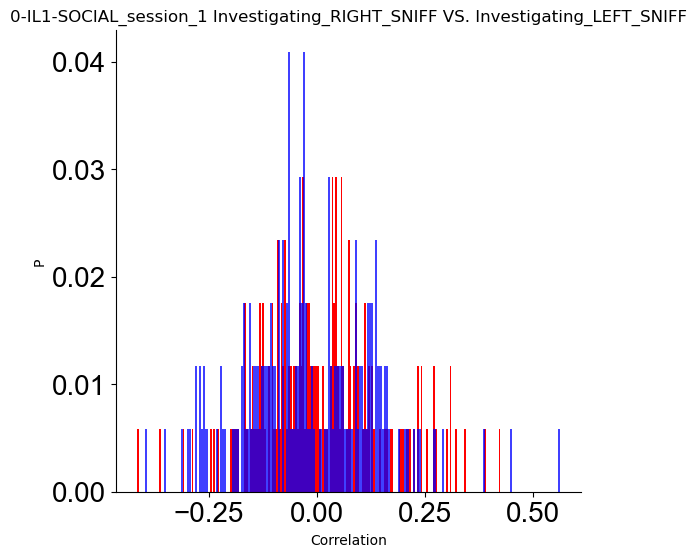

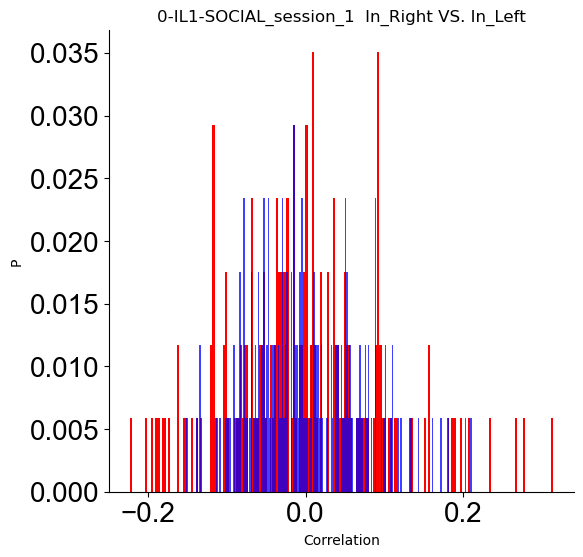

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


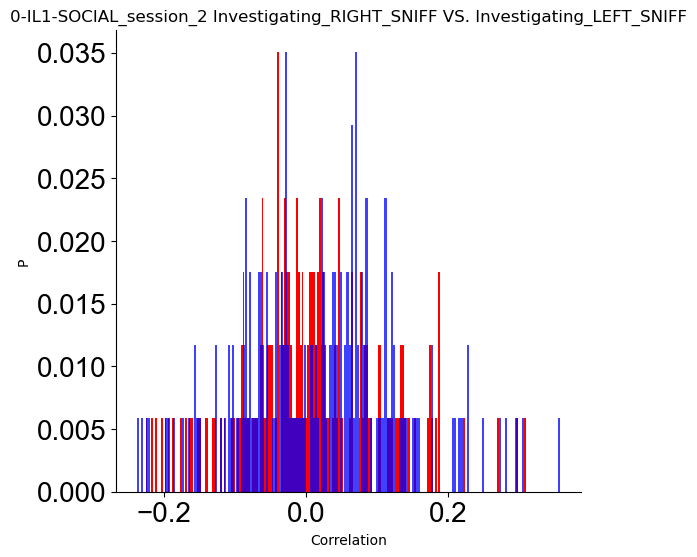

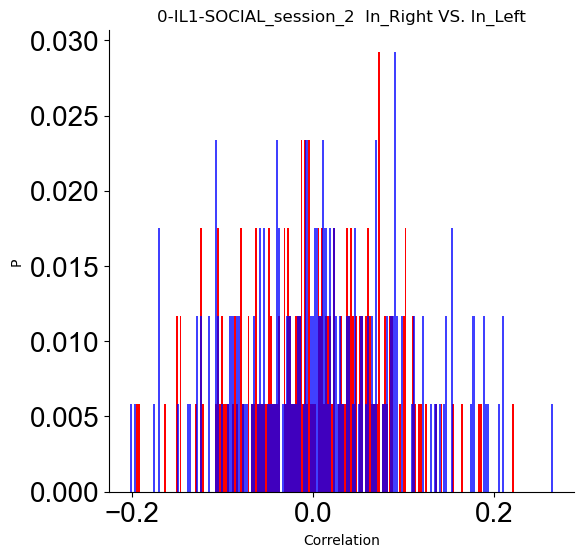

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


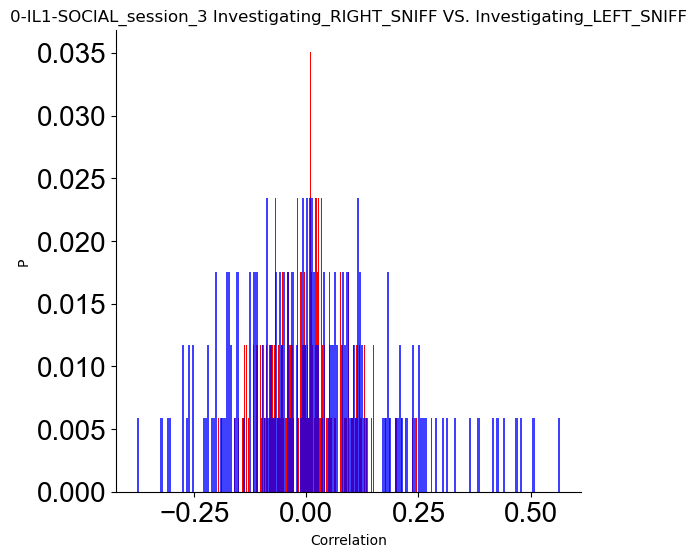

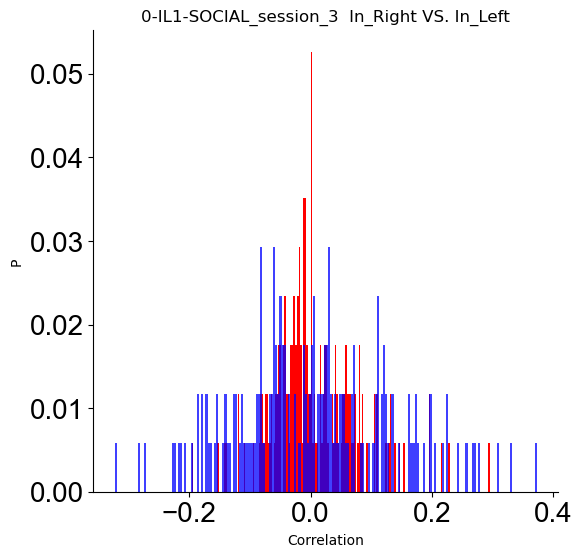

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


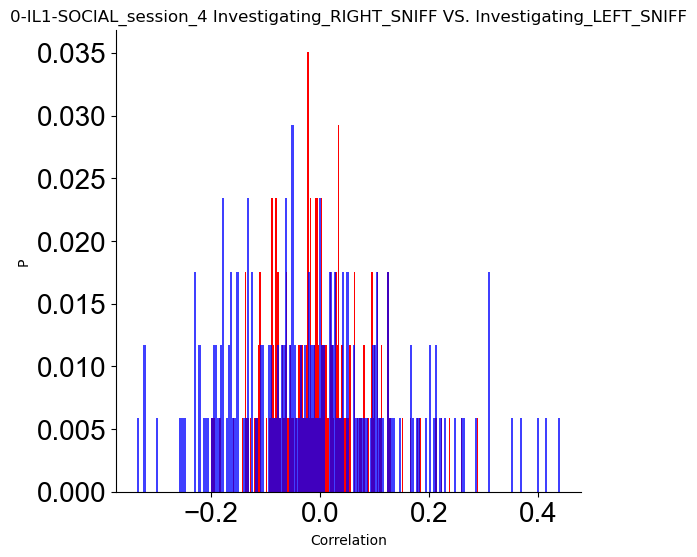

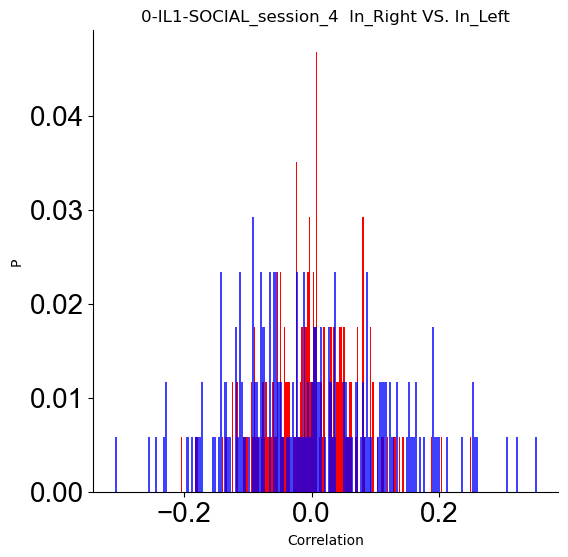

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [ ]:
print('IL1_Day0')

IL1_Day0_FWHM_list = []

Investigating_RIGHT_SNIFF_1_chain = []
Investigating_LEFT_SNIFF_1_chain = []
In_right_1_chain = []
In_left_1_chain = []
In_all_1_chain = []
Investigating_RIGHT_SNIFF_2_chain = []
Investigating_LEFT_SNIFF_2_chain = []
In_right_2_chain = []
In_left_2_chain = []
In_all_2_chain = []
Investigating_RIGHT_SNIFF_3_chain = []
Investigating_LEFT_SNIFF_3_chain = []
In_right_3_chain = []
In_left_3_chain = []
In_all_3_chain = []
Investigating_RIGHT_SNIFF_4_chain = []
Investigating_LEFT_SNIFF_4_chain = []
In_right_4_chain = []
In_left_4_chain = []
In_all_4_chain = []



for i in range(len(IL1_Day0_list)):
    
    mouse_name = IL1_Day0_list[i]
    
    print('Processing', mouse_name)
    
    mice = os.path.join(root_path, mouse_name)
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx")
    event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx")
    event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx")
    event4 = os.path.join(root_path, mouse_name, "event4_Con.xlsx")
    
    # 选择FPS
    if mouse_name.split('_')[0] in ['0-IL1-SOCIAL',]:
        fps = 15
    else:
        fps = 20
        
    dfLabeled, session_1, session_2, session_3, session_4 = add_event_label(trace, event1, event2, event3, event4)
    session_list = [session_1, session_2, session_3, session_4]
    sessionName_list = ['session_1', 'session_2', 'session_3', 'session_4']
    
    for session_index in range(len(sessionName_list)):
            
            session = session_list[session_index]
            sessionName = sessionName_list[session_index]
            
            Investigating_RIGHT_SNIFF_df = check_frame_interval(session, 'Investigating_RIGHT_SNIFF')
            Investigating_LEFT_SNIFF_df = check_frame_interval(session, 'Investigating_LEFT_SNIFF') 
            In_right_df = check_frame_interval(session, 'In_right')
            In_left_df = check_frame_interval(session, 'In_left')
            In_all_df = check_frame_interval(session, 'In_all')
            
            Investigating_RIGHT_SNIFF_corrs = corr_list(Investigating_RIGHT_SNIFF_df)
            Investigating_LEFT_SNIFF_corrs = corr_list(Investigating_LEFT_SNIFF_df)
            In_right_corrs = corr_list(In_right_df)
            In_left_corrs = corr_list(In_left_df)
            In_all_corrs = corr_list(In_all_df)


            # loop and update chain
            if sessionName == 'session_1':
                Investigating_RIGHT_SNIFF_1_chain = itertools.chain(Investigating_RIGHT_SNIFF_1_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_1_chain = itertools.chain(Investigating_LEFT_SNIFF_1_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_1_chain = itertools.chain(In_right_1_chain,In_right_corrs)
                In_left_1_chain = itertools.chain(In_left_1_chain,In_left_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
            elif sessionName == 'session_2':
                Investigating_RIGHT_SNIFF_2_chain = itertools.chain(Investigating_RIGHT_SNIFF_2_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_2_chain = itertools.chain(Investigating_LEFT_SNIFF_2_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_2_chain = itertools.chain(In_right_2_chain,In_right_corrs)
                In_left_2_chain = itertools.chain(In_left_2_chain,In_left_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
            elif sessionName == 'session_3':
                Investigating_RIGHT_SNIFF_3_chain = itertools.chain(Investigating_RIGHT_SNIFF_3_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_3_chain = itertools.chain(Investigating_LEFT_SNIFF_3_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_3_chain = itertools.chain(In_right_3_chain,In_right_corrs)
                In_left_3_chain = itertools.chain(In_left_3_chain,In_left_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
            else :
                Investigating_RIGHT_SNIFF_4_chain = itertools.chain(Investigating_RIGHT_SNIFF_4_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_4_chain = itertools.chain(Investigating_LEFT_SNIFF_4_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_4_chain = itertools.chain(In_right_4_chain,In_right_corrs)
                In_left_4_chain = itertools.chain(In_left_4_chain,In_left_corrs)
                In_all_4_chain = itertools.chain(In_all_4_chain,In_all_corrs)
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" Investigating_RIGHT_SNIFF VS. Investigating_LEFT_SNIFF"
            overlaid_histogram(figsize,Investigating_RIGHT_SNIFF_corrs, Investigating_LEFT_SNIFF_corrs, n_bins = 200, 
                            data1_name="IL1_Day0_Investigating_RIGHT_SNIFF", data1_color="red", 
                            data2_name="IL1_Day0_Investigating_LEFT_SNIFF", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer3/{title}.png')  # 保存图像
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+"  In_Right VS. In_Left"
            overlaid_histogram(figsize,In_right_corrs, In_left_corrs, n_bins = 200, 
                            data1_name="IL1_Day0_In_Right", data1_color="red", 
                            data2_name="IL1_Day0_In_Left", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer3/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        'Investigating_RIGHT_SNIFF FWHM':FWHM(Investigating_RIGHT_SNIFF_corrs),
                        'Investigating_LEFT_SNIFF FWHM':FWHM(Investigating_LEFT_SNIFF_corrs),
                        'In_right FWHM':FWHM(In_right_corrs),
                        'In_left FWHM':FWHM(In_left_corrs),
                        'In_all FWHM':FWHM(In_all_corrs)}
            IL1_Day0_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            IL1_Day0_FWHM_list.append(IL1_Day0_FWHM)

IL1_Day0_FWHM_DF = pd.concat(IL1_Day0_FWHM_list)
IL1_Day0_FWHM_DF.to_csv('C:/Users/卡塔利纳的杰克巴尔多/Desktop/IL1_Day0_FWHM.csv')

# PL2，4个session

In [ ]:
root_path = 'E:/山东第一医科大学/New Data/PL2/Social'
PL2_Day0_list = ['0-PL2-SOCIAL',]

PL2_Day0
Processing 0-PL2-SOCIAL


C:\Windows\Temp\ipykernel_10772\1261750801.py:5: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df, index_col=0)
C:\Windows\Temp\ipykernel_10772\1261750801.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2.drop(columns='index_col', inplace=True)
C:\Windows\Temp\ipykernel_10772\1261750801.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

The df shape of session 1: (7872, 18)
The df shape of session 2: (8600, 18)
The df shape of session 3: (8591, 18)
The df shape of session 4: (7528, 18)
 


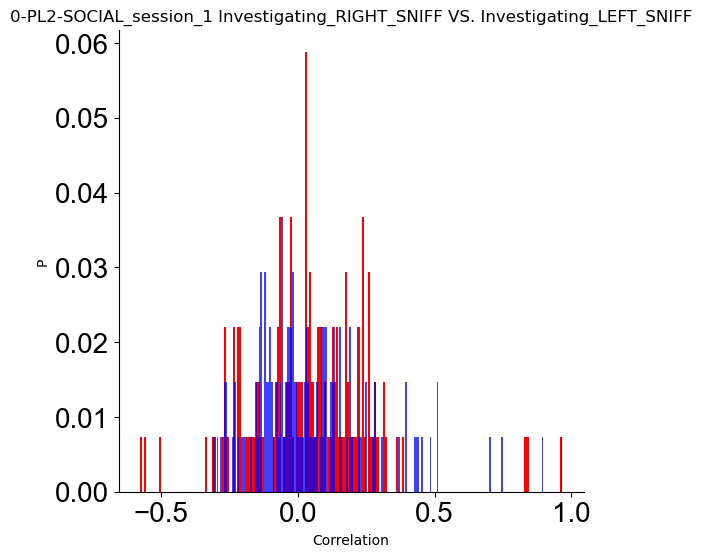

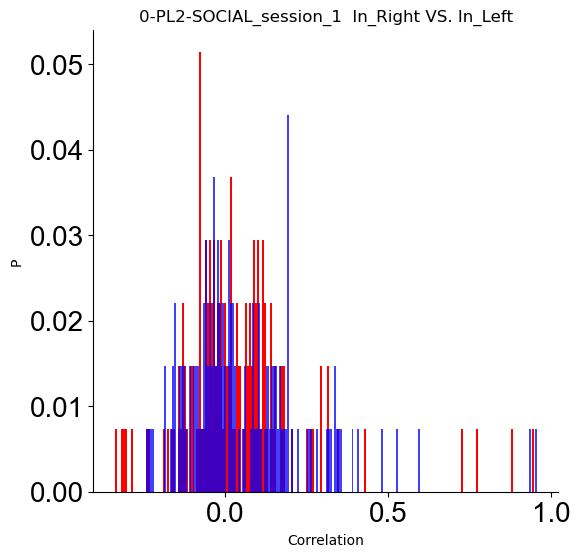

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


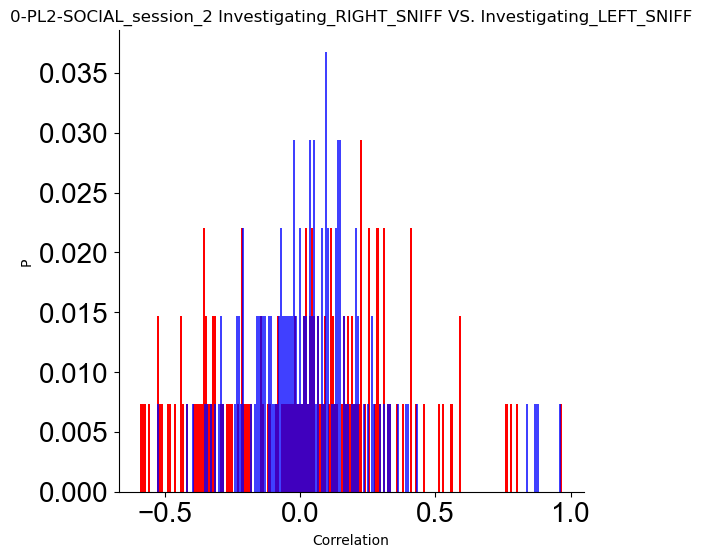

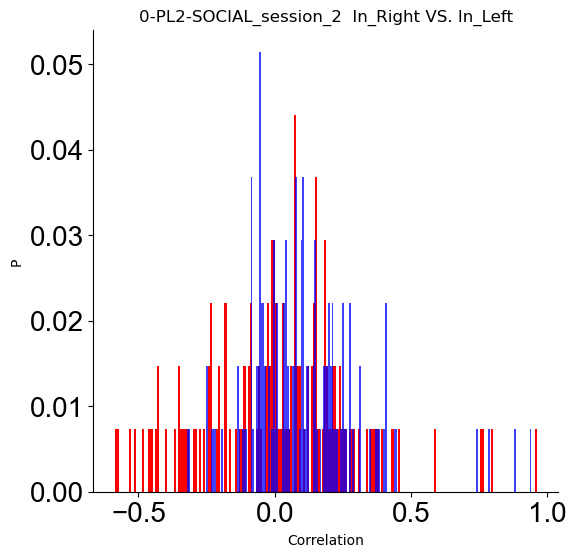

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


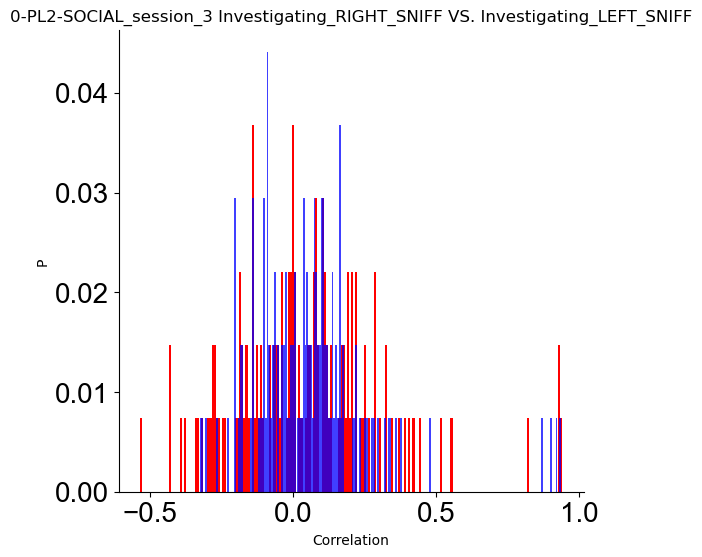

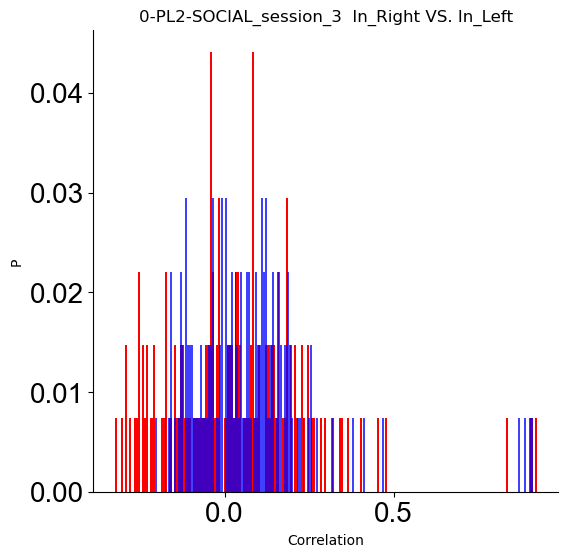

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


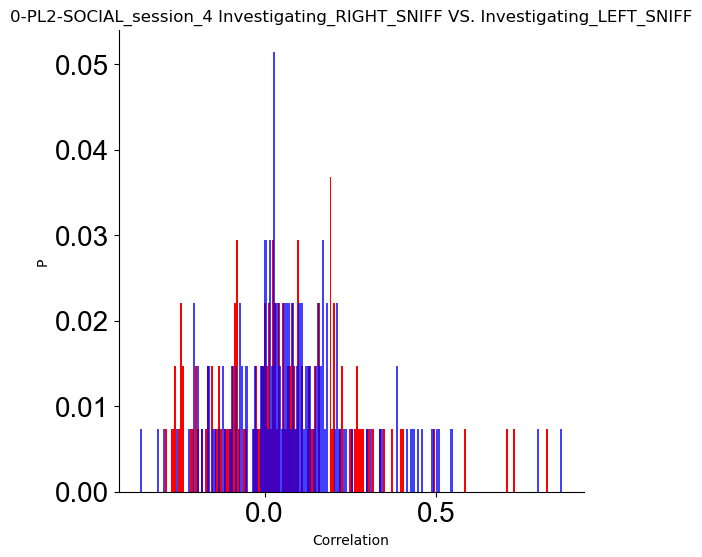

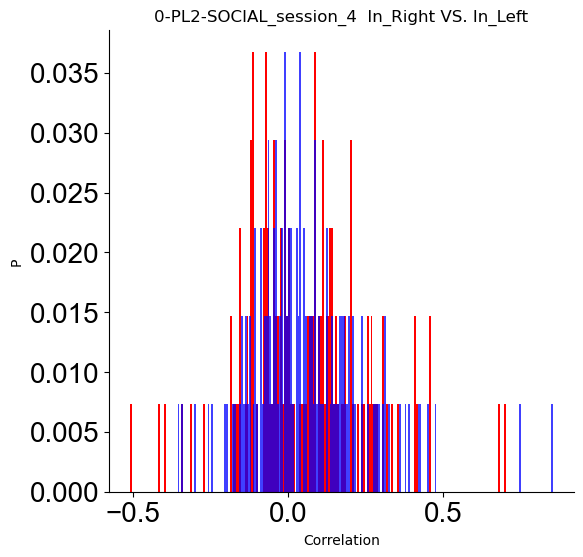

d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Windows\Temp\ipykernel_10772\3491546413.py:75: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(distribute)    # 分布的均值
d:\anaconda3\envs\core1\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [ ]:
print('PL2_Day0')

PL2_Day0_FWHM_list = []

Investigating_RIGHT_SNIFF_1_chain = []
Investigating_LEFT_SNIFF_1_chain = []
In_right_1_chain = []
In_left_1_chain = []
In_all_1_chain = []
Investigating_RIGHT_SNIFF_2_chain = []
Investigating_LEFT_SNIFF_2_chain = []
In_right_2_chain = []
In_left_2_chain = []
In_all_2_chain = []
Investigating_RIGHT_SNIFF_3_chain = []
Investigating_LEFT_SNIFF_3_chain = []
In_right_3_chain = []
In_left_3_chain = []
In_all_3_chain = []
Investigating_RIGHT_SNIFF_4_chain = []
Investigating_LEFT_SNIFF_4_chain = []
In_right_4_chain = []
In_left_4_chain = []
In_all_4_chain = []


for i in range(len(PL2_Day0_list)):
    
    mouse_name = PL2_Day0_list[i]
    
    print('Processing', mouse_name)
    
    mice = os.path.join(root_path, mouse_name)
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    event1 = os.path.join(root_path, mouse_name, "event1_Con.xlsx")
    event2 = os.path.join(root_path, mouse_name, "event2_Con.xlsx")
    event3 = os.path.join(root_path, mouse_name, "event3_Con.xlsx")
    event4 = os.path.join(root_path, mouse_name, "event4_Con.xlsx")

    
    # 选择FPS
    if mouse_name.split('_')[0] in ['0-PL2-SOCIAL',]:
        fps = 15
    else:
        fps = 20
        
    dfLabeled, session_1, session_2, session_3,session_4 = add_event_label(trace, event1, event2, event3,event4)
    session_list = [session_1, session_2, session_3, session_4]
    sessionName_list = ['session_1', 'session_2', 'session_3','session_4']
    
    for session_index in range(len(sessionName_list)):
            
            session = session_list[session_index]
            sessionName = sessionName_list[session_index]
            
            Investigating_RIGHT_SNIFF_df = check_frame_interval(session, 'Investigating_RIGHT_SNIFF')
            Investigating_LEFT_SNIFF_df = check_frame_interval(session, 'Investigating_LEFT_SNIFF') 
            In_right_df = check_frame_interval(session, 'In_right')
            In_left_df = check_frame_interval(session, 'In_left')
            In_all_df = check_frame_interval(session, 'In_all')
            
            Investigating_RIGHT_SNIFF_corrs = corr_list(Investigating_RIGHT_SNIFF_df)
            Investigating_LEFT_SNIFF_corrs = corr_list(Investigating_LEFT_SNIFF_df)
            In_right_corrs = corr_list(In_right_df)
            In_left_corrs = corr_list(In_left_df)
            In_all_corrs = corr_list(In_all_df)


            # loop and update chain
            if sessionName == 'session_1':
                Investigating_RIGHT_SNIFF_1_chain = itertools.chain(Investigating_RIGHT_SNIFF_1_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_1_chain = itertools.chain(Investigating_LEFT_SNIFF_1_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_1_chain = itertools.chain(In_right_1_chain,In_right_corrs)
                In_left_1_chain = itertools.chain(In_left_1_chain,In_left_corrs)
                In_all_1_chain = itertools.chain(In_all_1_chain,In_all_corrs)
            elif sessionName == 'session_2':
                Investigating_RIGHT_SNIFF_2_chain = itertools.chain(Investigating_RIGHT_SNIFF_2_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_2_chain = itertools.chain(Investigating_LEFT_SNIFF_2_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_2_chain = itertools.chain(In_right_2_chain,In_right_corrs)
                In_left_2_chain = itertools.chain(In_left_2_chain,In_left_corrs)
                In_all_2_chain = itertools.chain(In_all_2_chain,In_all_corrs)
            elif sessionName == 'session_3':
                Investigating_RIGHT_SNIFF_3_chain = itertools.chain(Investigating_RIGHT_SNIFF_3_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_3_chain = itertools.chain(Investigating_LEFT_SNIFF_3_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_3_chain = itertools.chain(In_right_3_chain,In_right_corrs)
                In_left_3_chain = itertools.chain(In_left_3_chain,In_left_corrs)
                In_all_3_chain = itertools.chain(In_all_3_chain,In_all_corrs)
            else :
                Investigating_RIGHT_SNIFF_4_chain = itertools.chain(Investigating_RIGHT_SNIFF_4_chain,Investigating_RIGHT_SNIFF_corrs)
                Investigating_LEFT_SNIFF_4_chain = itertools.chain(Investigating_LEFT_SNIFF_4_chain,Investigating_LEFT_SNIFF_corrs)
                In_right_4_chain = itertools.chain(In_right_4_chain,In_right_corrs)
                In_left_4_chain = itertools.chain(In_left_4_chain,In_left_corrs)
                In_all_4_chain = itertools.chain(In_all_4_chain,In_all_corrs)
        
            # 绘图
            figsize = (6,6)
            title = mouse_name+"_"+sessionName+" Investigating_RIGHT_SNIFF VS. Investigating_LEFT_SNIFF"
            overlaid_histogram(figsize,Investigating_RIGHT_SNIFF_corrs, Investigating_LEFT_SNIFF_corrs, n_bins = 200, 
                            data1_name="PL2_Day0_Investigating_RIGHT_SNIFF", data1_color="red", 
                            data2_name="PL2_Day0_Investigating_LEFT_SNIFF", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer4/{title}.png')  # 保存图像
            plt.show()

            figsize = (6,6)
            title = mouse_name+"_"+sessionName+"  In_Right VS. In_Left"
            overlaid_histogram(figsize,In_right_corrs, In_left_corrs, n_bins = 200, 
                            data1_name="PL2_Day0_In_Right", data1_color="red", 
                            data2_name="PL2_Day0_In_Left", data2_color="blue")
            plt.title(title)          # 添加标题
            plt.xlabel("Correlation") # 添加X轴标签
            plt.ylabel("P")           # 添加Y轴标签
            plt.savefig(f'C:/Users/卡塔利纳的杰克巴尔多/Desktop/Figer4/{title}.png')  # 保存图像
            plt.show()

            # save FWHM
            FWHM_dic = {'mouseName':mouse_name,
                        'whichSession':sessionName,
                        'Investigating_RIGHT_SNIFF FWHM':FWHM(Investigating_RIGHT_SNIFF_corrs),
                        'Investigating_LEFT_SNIFF FWHM':FWHM(Investigating_LEFT_SNIFF_corrs),
                        'In_right FWHM':FWHM(In_right_corrs),
                        'In_left FWHM':FWHM(In_left_corrs),
                        'In_all FWHM':FWHM(In_all_corrs)}
            PL2_Day0_FWHM = pd.DataFrame.from_dict(FWHM_dic, orient='index').T
            PL2_Day0_FWHM_list.append(PL2_Day0_FWHM)

PL2_Day0_FWHM_DF = pd.concat(PL2_Day0_FWHM_list)
PL2_Day0_FWHM_DF.to_csv('C:/Users/卡塔利纳的杰克巴尔多/Desktop/PL2_Day0_FWHM.csv')